# Vegetation Manhours — PyTorch Tabular Network

Same splits, tier schemes and reporting as the CatBoost notebook, so results are directly comparable.

| Split | Role |
|---|---|
| Train | Fits the preprocessor and weights (a feeder slice of Train drives early stopping) |
| Validation | Hyperparameter / loss / weight-strength selection only |
| Test | Confirmation; compared with the CatBoost champion on identical rows |
| Holdout | Scored once behind `READY_FOR_FINAL_HOLDOUT`, after refitting on Train+Validation+Test |

**Model:** categorical embeddings + residual MLP, one head per accessibility regime (or two separate networks).
Each head outputs a point prediction plus P10 / P90 (non-crossing by construction).

**Losses:** point head uses `l1` (`nn.L1Loss`, identical to MAE → comparable to CatBoost `MAE`) or `smooth_l1`
(Huber-style). P10 / P90 heads use pinball loss. Point loss is **sample-weighted** by tier badness from the CatBoost
CV (primary tier scheme); the weight strength is searched from 0, so Validation can reject weighting.

**Reporting:** span / feeder metrics, hour-tier confusion, and the 24-class accessibility × area × tier risk tables
(hour and volume tiers) with the investigate list.

**Requires** `run_veg_pipeline.ipynb` to have run (full-feature splits + `final_decisions.json`).

## 0. Configuration

In [1]:
import copy
import os
import sys
import time

import joblib
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

current_dir = "/mnt/projects/VEG_Contractors/2026unitization/2026unitization/notebooks"
# Get the parent directory of the current file
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Construct the path to the 'src/modeling' folder
modeling_dir = os.path.join(parent_dir, "src", "modeling")
# Add 'src/modeling' to the system path
sys.path.insert(0, modeling_dir)
import veg_pipeline_updated as vp 

READY_FOR_FINAL_HOLDOUT = True   # <-- BREAKPOINT
RUN_MODE = os.environ.get("VEG_RUN_MODE", "full")
SHOW_PLOTS = True

OUTPUT_DIR = os.environ.get("VEG_OUTPUT_DIR", "./deployment")
INPUT_DIR = os.environ.get("VEG_INPUT_DIR", "../input_data")
FULL_SPLIT_DIR = os.path.join(OUTPUT_DIR, "splits", "full_features")
NN_DIR = os.path.join(OUTPUT_DIR, "nn")
FIG_DIR = os.path.join(NN_DIR, "figures")
DECISIONS_PATH = os.path.join(OUTPUT_DIR, "final_decisions.json")
CATBOOST_TEST_PREDS = os.path.join(OUTPUT_DIR, "dev_test_predictions.csv")
CATBOOST_TEST_QUANTILES = os.path.join(OUTPUT_DIR, "dev_test_quantiles.csv")
os.makedirs(FIG_DIR, exist_ok=True)

FAST = RUN_MODE == "fast"
NN_CFG = {
    "n_trials": 3 if FAST else 30,
    "max_epochs": 15 if FAST else 300,
    "patience": 4 if FAST else 25,
    "es_feeder_share": 0.15,
    "n_seeds_final": 1 if FAST else 5,
    "min_category_count": 20,
    "skew_log_threshold": 2.0,
    "clip_z": 6.0,
    "w_span_mae": 0.5,
    "w_feeder_wape": 0.5,
    "quantile_alphas": (0.10, 0.90),
    "quantile_loss_weight": 0.5,          # weight of the P10/P90 pinball terms vs the point loss
    "use_chosen_area_only": True,
    "weight_scheme": "primary",           # "primary" | "hours" | "volume" | None (no weighting)
    "run_group_permutation": True,
    "tune": "auto",
}
LOSS_CHOICES = ["l1", "smooth_l1"]
ARCH_CHOICES = ["shared_two_head", "split"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = vp.RANDOM_STATE


def fig(name):
    return os.path.join(FIG_DIR, name)


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print(f"Device: {DEVICE} | RUN_MODE={RUN_MODE} | READY_FOR_FINAL_HOLDOUT={READY_FOR_FINAL_HOLDOUT}")

Device: cpu | RUN_MODE=full | READY_FOR_FINAL_HOLDOUT=True


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load splits + CatBoost decisions

In [2]:
FULL_X, FULL_Y, FULL_META, MANIFEST = vp.load_full_splits(FULL_SPLIT_DIR)
DECISIONS = vp.read_json(DECISIONS_PATH)

SCHEMES = {n: vp.TierScheme.from_dict(d) for n, d in DECISIONS["tier_schemes"].items()}
PRIMARY = DECISIONS["primary_tier_scheme"]
HOUR_CUTS = SCHEMES["hours"].cuts
CHOSEN_AREA_COL = DECISIONS["chosen_area_column"]
DROPPED_AREA_COLS = DECISIONS["dropped_area_columns"]

weight_scheme = PRIMARY if NN_CFG["weight_scheme"] == "primary" else NN_CFG["weight_scheme"]
WEIGHTING = (vp.TierWeighting.from_dict(DECISIONS["tier_weightings"][weight_scheme])
             if weight_scheme and weight_scheme in DECISIONS["tier_weightings"] else None)

FEATURES = [c for c in MANIFEST["feature_columns"]
            if c not in vp.LEGACY_TIER_FEATURE_COLS
            and not (NN_CFG["use_chosen_area_only"] and c in DROPPED_AREA_COLS)]
CATEGORICAL = [c for c in MANIFEST["categorical_columns"] if c in FEATURES]
vp.assert_no_leaky_columns(FEATURES)
for a, b in [("train", "valid"), ("train", "test"), ("train", "holdout"), ("valid", "test"),
             ("valid", "holdout"), ("test", "holdout")]:
    assert set(FULL_META[a]["feeder"]).isdisjoint(FULL_META[b]["feeder"]), f"feeder overlap {a}/{b}"
print(f"{len(FEATURES)} features ({len(CATEGORICAL)} categorical) | area {CHOSEN_AREA_COL} | primary tiers {PRIMARY}")
print(f"Hour cuts {HOUR_CUTS} | volume cuts {SCHEMES['volume'].cuts}")
print(f"Sample weighting scheme: {weight_scheme}" + (f" badness {WEIGHTING.badness}" if WEIGHTING else " (off)"))

133 features (5 categorical) | area area_lcxfm | primary tiers hours
Hour cuts {'Accessible': [2.1, 3.5, 5.0], 'Inaccessible': [3.5, 5.5, 8.0]} | volume cuts {'Accessible': [3053.31, 9151.44, 19030.37], 'Inaccessible': [3053.31, 9151.44, 19030.37]}
Sample weighting scheme: hours badness {'Accessible': [0.9178, 0.5008, 0.8989, 1.0], 'Inaccessible': [0.8081, 0.7028, 0.5835, 1.0]}


## 2. Preprocessor (fit on the fitting rows only)
Categoricals → integer ids (0 = unknown / rare). Binary numerics pass through as 0/1 (continuous path).
Other numerics → Train-median fill, signed log1p when heavily skewed, z-score, clip.

In [3]:
class TabularPreprocessor:
    def __init__(self, features, categorical, min_category_count=20, skew_threshold=2.0, clip_z=6.0):
        self.features, self.categorical = list(features), list(categorical)
        self.numeric = [c for c in self.features if c not in self.categorical]
        self.min_count, self.skew_threshold, self.clip_z = min_category_count, skew_threshold, clip_z

    def fit(self, X: pd.DataFrame):
        self.vocab = {}
        for c in self.categorical:
            counts = X[c].astype(str).value_counts()
            self.vocab[c] = {v: i + 1 for i, v in enumerate(sorted(counts[counts >= self.min_count].index))}
        num = X[self.numeric].apply(pd.to_numeric, errors="coerce")
        self.medians = num.median().fillna(0.0)
        num = num.fillna(self.medians)
        self.binary = [c for c in self.numeric if set(np.unique(num[c])) <= {0.0, 1.0}]
        self.continuous = [c for c in self.numeric if c not in self.binary]
        skew = num[self.continuous].skew().fillna(0)
        self.log_cols = skew[skew.abs() > self.skew_threshold].index.tolist()
        num = self._log(num)
        self.mean = num[self.continuous].mean()
        self.std = num[self.continuous].std().replace(0, 1.0).fillna(1.0)
        return self

    def _log(self, num):
        num = num.copy()
        for c in self.log_cols:
            num[c] = np.sign(num[c]) * np.log1p(np.abs(num[c]))
        return num

    def state(self) -> dict:
        """Plain-data state (safe to pickle / reload without this class definition)."""
        return {k: getattr(self, k) for k in ["features", "categorical", "numeric", "min_count", "skew_threshold",
                                              "clip_z", "vocab", "medians", "binary", "continuous", "log_cols",
                                              "mean", "std"]}

    @classmethod
    def from_state(cls, state: dict):
        obj = cls.__new__(cls)
        obj.__dict__.update(state)
        return obj

    @property
    def cardinalities(self):
        return [len(self.vocab[c]) + 1 for c in self.categorical]

    @property
    def n_numeric(self):
        return len(self.continuous) + len(self.binary)

    def transform(self, X: pd.DataFrame):
        num = self._log(X[self.numeric].apply(pd.to_numeric, errors="coerce").fillna(self.medians))
        z = ((num[self.continuous] - self.mean) / self.std).clip(-self.clip_z, self.clip_z)
        x_num = np.hstack([z.to_numpy(np.float32), num[self.binary].to_numpy(np.float32)])
        x_cat = (np.stack([X[c].astype(str).map(self.vocab[c]).fillna(0).to_numpy(np.int64)
                           for c in self.categorical], axis=1)
                 if self.categorical else np.zeros((len(X), 0), np.int64))
        return x_num, x_cat

## 3. Network + losses
Per head: point = softplus(a); P10 = point − softplus(b); P90 = point + softplus(c) → P10 ≤ point ≤ P90 always.
P10 is clamped at 0 when predicting.

In [4]:
def embedding_dim(cardinality):
    return int(min(16, max(2, round(1.6 * cardinality ** 0.56))))


class ResidualBlock(nn.Module):
    def __init__(self, width, dropout):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(width), nn.Linear(width, width), nn.GELU(),
                                 nn.Dropout(dropout), nn.Linear(width, width))

    def forward(self, x):
        return x + self.net(x)


class TabularResNet(nn.Module):
    def __init__(self, n_numeric, cardinalities, width=256, n_blocks=3, dropout=0.15, emb_dropout=0.05,
                 n_heads=2, init_values=(2.0, 2.0)):
        super().__init__()
        self.n_heads = n_heads
        self.embeddings = nn.ModuleList([nn.Embedding(c, embedding_dim(c)) for c in cardinalities])
        emb_total = sum(embedding_dim(c) for c in cardinalities)
        self.emb_dropout = nn.Dropout(emb_dropout)
        self.inp = nn.Sequential(nn.Linear(n_numeric + emb_total, width), nn.GELU())
        self.blocks = nn.Sequential(*[ResidualBlock(width, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(nn.LayerNorm(width), nn.Linear(width, n_heads * 3))
        with torch.no_grad():
            bias = []
            for v in list(init_values)[:n_heads]:
                v = max(float(v), 1e-3)
                inv = float(np.log(np.expm1(v)))
                bias += [inv, float(np.log(np.expm1(0.5 * v))), float(np.log(np.expm1(0.8 * v)))]
            self.head[-1].bias.copy_(torch.tensor(bias))
            self.head[-1].weight.mul_(0.1)

    def forward(self, x_num, x_cat, head_idx):
        parts = [x_num]
        if len(self.embeddings):
            parts.append(self.emb_dropout(torch.cat([e(x_cat[:, i]) for i, e in enumerate(self.embeddings)], 1)))
        raw = self.head(self.blocks(self.inp(torch.cat(parts, 1)))).view(-1, self.n_heads, 3)
        raw = raw[torch.arange(len(head_idx), device=raw.device), head_idx]      # (batch, 3)
        sp = nn.functional.softplus(raw)
        point = sp[:, 0]
        return point, point - sp[:, 1], point + sp[:, 2]


def point_loss(spec, pred, y, w):
    if spec["loss"] == "l1":
        per = (pred - y).abs()                                          # == MAE
    elif spec["loss"] == "smooth_l1":
        per = nn.functional.smooth_l1_loss(pred, y, beta=spec.get("smooth_beta", 1.0), reduction="none")
    else:
        raise ValueError(spec["loss"])
    return (w * per).sum() / w.sum()


def pinball_loss(q_pred, y, alpha):
    d = y - q_pred
    return torch.maximum(alpha * d, (alpha - 1) * d).mean()


def total_loss(spec, outputs, y, w):
    point, lo, hi = outputs
    a_lo, a_hi = NN_CFG["quantile_alphas"]
    return point_loss(spec, point, y, w) + NN_CFG["quantile_loss_weight"] * (
        pinball_loss(lo, y, a_lo) + pinball_loss(hi, y, a_hi))

## 4. Training utilities

In [5]:
def feeder_es_split(meta: pd.DataFrame, share, seed):
    rng = np.random.default_rng(seed)
    feeders = meta["feeder"].unique()
    es = set(rng.choice(feeders, size=max(1, int(round(len(feeders) * share))), replace=False))
    in_es = meta["feeder"].isin(es).to_numpy()
    return meta.index[~in_es], meta.index[in_es]


def to_tensors(pre, X, y, head, weight=None):
    x_num, x_cat = pre.transform(X)
    t = [torch.from_numpy(x_num), torch.from_numpy(x_cat), torch.from_numpy(np.asarray(head, np.int64))]
    if y is not None:
        t.append(torch.from_numpy(np.asarray(y, np.float32)))
        t.append(torch.from_numpy(np.ones(len(X), np.float32) if weight is None else np.asarray(weight, np.float32)))
    return t


def predict_tensors(model, tensors, batch_size=4096):
    model.eval()
    outs = [[], [], []]
    with torch.no_grad():
        for i in range(0, len(tensors[0]), batch_size):
            res = model(*[t[i:i + batch_size].to(DEVICE) for t in tensors[:3]])
            for k in range(3):
                outs[k].append(res[k].cpu().numpy())
    point, lo, hi = (np.concatenate(o) for o in outs)
    return point, np.clip(lo, 0, None), hi


def train_network(model, train_t, es_t, spec, seed, max_epochs, patience, verbose=False):
    opt = torch.optim.AdamW(model.parameters(), lr=spec["lr"], weight_decay=spec["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=max(2, patience // 4))
    loader = DataLoader(TensorDataset(*train_t), batch_size=spec["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed),
                        drop_last=len(train_t[0]) > spec["batch_size"])
    es_y = es_t[3].numpy()
    best, best_state, best_epoch, wait, epoch = np.inf, None, 0, 0, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xn, xc, hd, yb, wb in loader:
            xn, xc, hd, yb, wb = (t.to(DEVICE) for t in (xn, xc, hd, yb, wb))
            opt.zero_grad(set_to_none=True)
            total_loss(spec, model(xn, xc, hd), yb, wb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        es_mae = float(np.mean(np.abs(predict_tensors(model, es_t)[0] - es_y)))   # unweighted MAE on ES slice
        sched.step(es_mae)
        if es_mae < best - 1e-4:
            best, best_state, best_epoch, wait = es_mae, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if wait >= patience:
                break
        if verbose and epoch % 10 == 0:
            print(f"    epoch {epoch}: ES MAE {es_mae:.4f} (best {best:.4f} @ {best_epoch})")
    model.load_state_dict(best_state)
    return model, {"best_es_mae": best, "best_epoch": best_epoch, "epochs_run": epoch}


class FittedNet:
    """One shared two-head network or an accessible/inaccessible pair, with preprocessors."""

    def __init__(self, spec):
        self.spec, self.parts, self.history = spec, {}, []

    def _groups(self, meta):
        if self.spec["arch"] == "shared_two_head":
            return {"shared": meta.index}
        return {seg: meta.index[meta["inaccessible"].eq(f).to_numpy()] for seg, f in vp.SEGMENTS.items()}

    def _heads(self, meta, idx):
        if self.spec["arch"] == "shared_two_head":
            return meta.loc[idx, "inaccessible"].to_numpy()
        return np.zeros(len(idx), np.int64)

    def fit(self, X, y, meta, seed, verbose=False):
        strength = self.spec.get("weight_strength", 0.0)
        for key, idx in self._groups(meta).items():
            fit_idx, es_idx = feeder_es_split(meta.loc[idx], NN_CFG["es_feeder_share"], seed)
            pre = TabularPreprocessor(FEATURES, CATEGORICAL, NN_CFG["min_category_count"],
                                      NN_CFG["skew_log_threshold"], NN_CFG["clip_z"]).fit(X.loc[fit_idx])
            n_heads = 2 if key == "shared" else 1
            init = ([float(y.loc[fit_idx][meta.loc[fit_idx, "inaccessible"].eq(f)].median()) for f in (0, 1)]
                    if n_heads == 2 else [float(y.loc[fit_idx].median())])
            w = (WEIGHTING.row_weights(X.loc[fit_idx], y.loc[fit_idx], meta.loc[fit_idx], strength)
                 if WEIGHTING is not None and strength > 0 else None)
            set_seed(seed)
            model = TabularResNet(pre.n_numeric, pre.cardinalities, self.spec["width"], self.spec["n_blocks"],
                                  self.spec["dropout"], self.spec["emb_dropout"], n_heads, init).to(DEVICE)
            train_t = to_tensors(pre, X.loc[fit_idx], y.loc[fit_idx], self._heads(meta, fit_idx), w)
            es_t = to_tensors(pre, X.loc[es_idx], y.loc[es_idx], self._heads(meta, es_idx))
            model, hist = train_network(model, train_t, es_t, self.spec, seed, NN_CFG["max_epochs"],
                                        NN_CFG["patience"], verbose)
            self.parts[key] = (pre, model)
            self.history.append({"part": key, **hist})
        return self

    def predict(self, X, meta):
        out = pd.DataFrame(np.nan, index=X.index, columns=["point", "p10", "p90"])
        meta = meta.reindex(X.index)
        for key, idx in self._groups(meta).items():
            if len(idx):
                pre, model = self.parts[key]
                out.loc[idx] = np.column_stack(predict_tensors(model, to_tensors(pre, X.loc[idx], None,
                                                                                 self._heads(meta, idx))))
        return out


def fit_ensemble(spec, fit_splits, seeds, verbose=False):
    X = pd.concat([FULL_X[s] for s in fit_splits])
    y = pd.concat([FULL_Y[s] for s in fit_splits]).reindex(X.index)
    meta = pd.concat([FULL_META[s] for s in fit_splits]).reindex(X.index)
    return [FittedNet(spec).fit(X, y, meta, seed, verbose) for seed in seeds]


def predict_ensemble(nets, split, X=None):
    """Seed-averaged point / P10 / P90 (averaging quantiles is a pragmatic approximation)."""
    X = FULL_X[split] if X is None else X
    preds = [n.predict(X, FULL_META[split]) for n in nets]
    return sum(preds) / len(preds)


def naive_reference(split):
    pred = pd.Series(0.0, index=FULL_X[split].index)
    for seg, f in vp.SEGMENTS.items():
        pred[FULL_META[split]["inaccessible"].eq(f).to_numpy()] = FULL_Y["train"][FULL_META["train"]["inaccessible"].eq(f)].median()
    y = FULL_Y[split]
    return float(np.mean(np.abs(y - pred))), vp.feeder_wape(y.to_numpy(), pred.to_numpy(), FULL_META[split]["feeder"].to_numpy())


NAIVE_VALID_MAE, NAIVE_VALID_WAPE = naive_reference("valid")


def valid_objective(point):
    y = FULL_Y["valid"]
    mae = float(np.mean(np.abs(y - point)))
    wape = vp.feeder_wape(y.to_numpy(), np.asarray(point), FULL_META["valid"]["feeder"].to_numpy())
    return NN_CFG["w_span_mae"] * mae / NAIVE_VALID_MAE + NN_CFG["w_feeder_wape"] * wape / NAIVE_VALID_WAPE

## 5. Hyperparameter, loss and weight-strength selection (fit Train → select on Validation)

In [6]:
NN_SPEC_PATH = os.path.join(NN_DIR, "nn_best_spec.json")
DEFAULT_SPEC = {"arch": "shared_two_head", "loss": "l1", "width": 256, "n_blocks": 3, "dropout": 0.15,
                "emb_dropout": 0.05, "lr": 1e-3, "weight_decay": 1e-4, "batch_size": 512, "weight_strength": 0.0}


def spec_from_trial(trial):
    spec = {
        "arch": trial.suggest_categorical("arch", ARCH_CHOICES),
        "loss": trial.suggest_categorical("loss", LOSS_CHOICES),
        "width": trial.suggest_categorical("width", [128, 256, 512]),
        "n_blocks": trial.suggest_int("n_blocks", 1, 4),
        "dropout": trial.suggest_float("dropout", 0.0, 0.4),
        "emb_dropout": trial.suggest_float("emb_dropout", 0.0, 0.3),
        "lr": trial.suggest_float("lr", 2e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        "weight_strength": trial.suggest_float("weight_strength", 0.0, 3.0) if WEIGHTING is not None else 0.0,
    }
    if spec["loss"] == "smooth_l1":
        spec["smooth_beta"] = trial.suggest_float("smooth_beta", 0.25, 3.0, log=True)
    return spec


check = {"features": FEATURES, "schemes": DECISIONS["tier_schemes"], "weight_scheme": weight_scheme,
         "quantile_alphas": list(NN_CFG["quantile_alphas"])}
saved = vp.read_json(NN_SPEC_PATH) if os.path.exists(NN_SPEC_PATH) else {}
saved_ok = all(saved.get(k) == v for k, v in check.items())
do_tune = NN_CFG["tune"] is True or (NN_CFG["tune"] == "auto" and not saved_ok)

if do_tune:
    optuna = vp.optuna

    def objective(trial):
        spec = spec_from_trial(trial)
        t0 = time.time()
        net = fit_ensemble(spec, ("train",), [SEED])[0]
        pred = net.predict(FULL_X["valid"], FULL_META["valid"])
        trial.set_user_attr("valid_mae", float(np.mean(np.abs(FULL_Y["valid"] - pred["point"]))))
        trial.set_user_attr("valid_cov80", float(((FULL_Y["valid"] >= pred["p10"]) & (FULL_Y["valid"] <= pred["p90"])).mean()))
        trial.set_user_attr("seconds", time.time() - t0)
        return valid_objective(pred["point"])

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    enq = {k: v for k, v in DEFAULT_SPEC.items() if WEIGHTING is not None or k != "weight_strength"}
    study.enqueue_trial(enq)
    study.enqueue_trial({**enq, "loss": "smooth_l1", "smooth_beta": 1.0})
    study.optimize(objective, n_trials=max(NN_CFG["n_trials"], 2), show_progress_bar=not FAST)
    trials = study.trials_dataframe()
    trials.to_csv(os.path.join(NN_DIR, "nn_trials.csv"), index=False)
    BEST_SPEC = spec_from_trial(optuna.trial.FixedTrial(study.best_trial.params))
    show_cols = [c for c in ["number", "value", "user_attrs_valid_mae", "user_attrs_valid_cov80", "params_arch",
                             "params_loss", "params_weight_strength", "params_width", "params_n_blocks",
                             "params_lr", "user_attrs_seconds"] if c in trials.columns]
    vp.show(trials.sort_values("value").head(10)[show_cols], "Top NN trials (Validation objective)")

    # Head-to-head at the best architecture: L1 vs smooth-L1, weighted vs unweighted
    rows = []
    for loss in LOSS_CHOICES:
        for strength in sorted({0.0, BEST_SPEC["weight_strength"]}):
            spec = {**BEST_SPEC, "loss": loss, "smooth_beta": BEST_SPEC.get("smooth_beta", 1.0),
                    "weight_strength": strength}
            pred = fit_ensemble(spec, ("train",), [SEED])[0].predict(FULL_X["valid"], FULL_META["valid"])
            rows.append({**vp.evaluate_combined(f"NN {loss} | w={strength:.2f}", FULL_Y["valid"], pred["point"],
                                                FULL_META["valid"], HOUR_CUTS),
                         "Valid_Objective": valid_objective(pred["point"])})
    vp.show(pd.DataFrame(rows).set_index("Model")[vp.COMPARE_COLS + ["Valid_Objective"]],
            "Loss x weighting comparison at best architecture (Validation)")
    vp.write_json({**check, "spec": BEST_SPEC, "best_value": study.best_value}, NN_SPEC_PATH)
else:
    BEST_SPEC = saved["spec"]
    print(f"Loaded NN spec from {NN_SPEC_PATH}")
print("BEST_SPEC:", BEST_SPEC)

Loaded NN spec from ./deployment/nn/nn_best_spec.json
BEST_SPEC: {'arch': 'shared_two_head', 'loss': 'smooth_l1', 'width': 128, 'n_blocks': 2, 'dropout': 0.21512666491601654, 'emb_dropout': 0.19874085465007435, 'lr': 0.002957585988039703, 'weight_decay': 5.111153416599798e-05, 'batch_size': 1024, 'weight_strength': 1.819460803620995, 'smooth_beta': 0.8492329752187834}


## 6. Seed ensemble (fit Train) → Validation + Test

    epoch 10: ES MAE 2.0216 (best 1.9769 @ 4)
    epoch 20: ES MAE 2.1915 (best 1.9769 @ 4)
    epoch 10: ES MAE 2.2460 (best 2.1028 @ 1)
    epoch 20: ES MAE 2.2981 (best 2.1028 @ 1)
    epoch 10: ES MAE 2.1706 (best 2.0046 @ 3)
    epoch 20: ES MAE 2.3230 (best 2.0046 @ 3)
    epoch 10: ES MAE 2.1032 (best 1.8947 @ 2)
    epoch 20: ES MAE 2.1536 (best 1.8947 @ 2)
    epoch 10: ES MAE 1.6761 (best 1.6218 @ 3)
    epoch 20: ES MAE 1.7337 (best 1.6218 @ 3)

Training history (early-stopping slice of Train)


,part,best_es_mae,best_epoch,epochs_run
0,shared,1.9769,4,29
1,shared,2.1028,1,26
2,shared,2.0046,3,28
3,shared,1.8947,2,27
4,shared,1.6218,3,28


Validation-fit scale factors: {'Accessible': 1.2442, 'Inaccessible': 0.9096}

VALIDATION (selection split)


,Accessible_MAE,Inaccessible_MAE,Combined_MAE,Combined_R2,Combined_Bias,Feeder_R2,Feeder_WAPE,Feeder_MdAPE,Feeder_Within_15pct,Feeder_Within_20pct,Feeder_Total_Bias_Pct,Accessible_TierAcc,Accessible_TierQWK,Inaccessible_TierAcc,Inaccessible_TierQWK
Model,,,,,,,,,,,,,,,
"NN (smooth_l1, w=1.82)",1.365,2.6827,1.9973,0.0918,-0.1322,0.8411,0.276,0.1985,0.3704,0.5,-0.0343,0.4026,0.4397,0.384,0.2812


NOTE: 9,103 bays map to more than one distinct 'protective_device' value - each collapsed to a single deterministic value to prevent double-counting in aggregation.
NOTE: 9,101 bays map to more than one distinct 'major_protective_device' value - each collapsed to a single deterministic value to prevent double-counting in aggregation.
Loaded protective-device map for 241,344 bays (protective_device, major_protective_device).
Protective-device match rate onto meta (4,159 rows): 100.0%


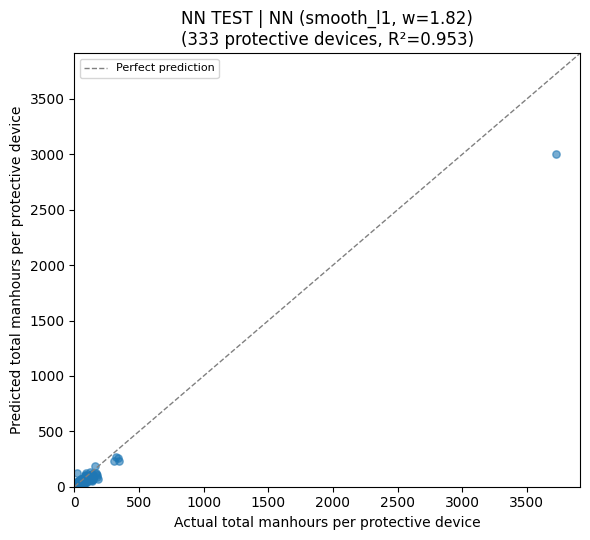

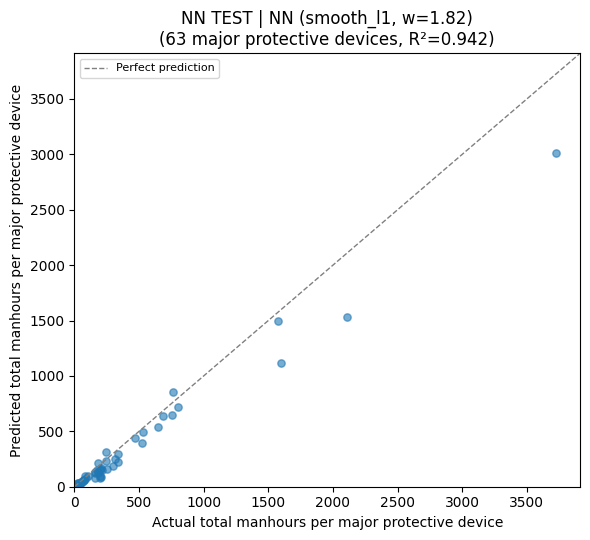


TEST - NN vs CatBoost (identical rows)


,Accessible_MAE,Inaccessible_MAE,Combined_MAE,Combined_R2,Combined_Bias,Feeder_R2,Feeder_WAPE,Feeder_MdAPE,Feeder_Within_15pct,Feeder_Within_20pct,Feeder_Total_Bias_Pct,Accessible_TierAcc,Accessible_TierQWK,Inaccessible_TierAcc,Inaccessible_TierQWK
Model,,,,,,,,,,,,,,,
CatBoost Weighted (volume tiers),1.6307,2.7257,2.1444,0.2627,-0.3747,0.9849,0.1256,0.2429,0.3889,0.4630,-0.0784,0.3410,0.4920,0.3936,0.4223
CatBoost Regression-opt + OOF scale,1.6892,2.6933,2.1602,0.2674,-0.3106,0.9854,0.1256,0.2386,0.4259,0.4815,-0.0650,0.2858,0.4588,0.3988,0.4312
CatBoost Weighted (hours tiers),1.6264,2.7370,2.1474,0.2581,-0.3806,0.9847,0.1259,0.2741,0.4074,0.4444,-0.0797,0.3193,0.4684,0.3870,0.4130
CatBoost Regression-opt [champion],1.6118,2.7319,2.1373,0.2608,-0.3964,0.9850,0.1259,0.1934,0.3889,0.5185,-0.0830,0.3510,0.4849,0.3901,0.4082
CatBoost Regression-opt + tier bias correction,1.5649,2.7915,2.1403,0.2255,-0.7716,0.9645,0.1791,0.2277,0.2963,0.4259,-0.1615,0.4221,0.5072,0.3649,0.3871
CatBoost Baseline (no road),1.5856,2.8341,2.1713,0.2114,-0.8022,0.9624,0.1804,0.2605,0.2407,0.3704,-0.1679,0.4348,0.4975,0.3685,0.4018
"NN (smooth_l1, w=1.82) + valid scale",1.7289,2.7728,2.2186,0.2017,-0.6841,0.9625,0.1824,0.3082,0.2778,0.4259,-0.1432,0.2591,0.4379,0.3757,0.4183
"NN (smooth_l1, w=1.82)",1.5596,2.6788,2.0846,0.2309,-0.8599,0.9534,0.1882,0.2395,0.3519,0.4074,-0.1800,0.4343,0.5048,0.4003,0.4439
CatBoost Road challenger (all features),1.5205,2.8549,2.1465,0.1730,-1.1090,0.9277,0.2388,0.2504,0.2963,0.4074,-0.2321,0.4547,0.5141,0.3388,0.3722


NN Test 80% interval coverage: 0.804 | mean width 6.36 h


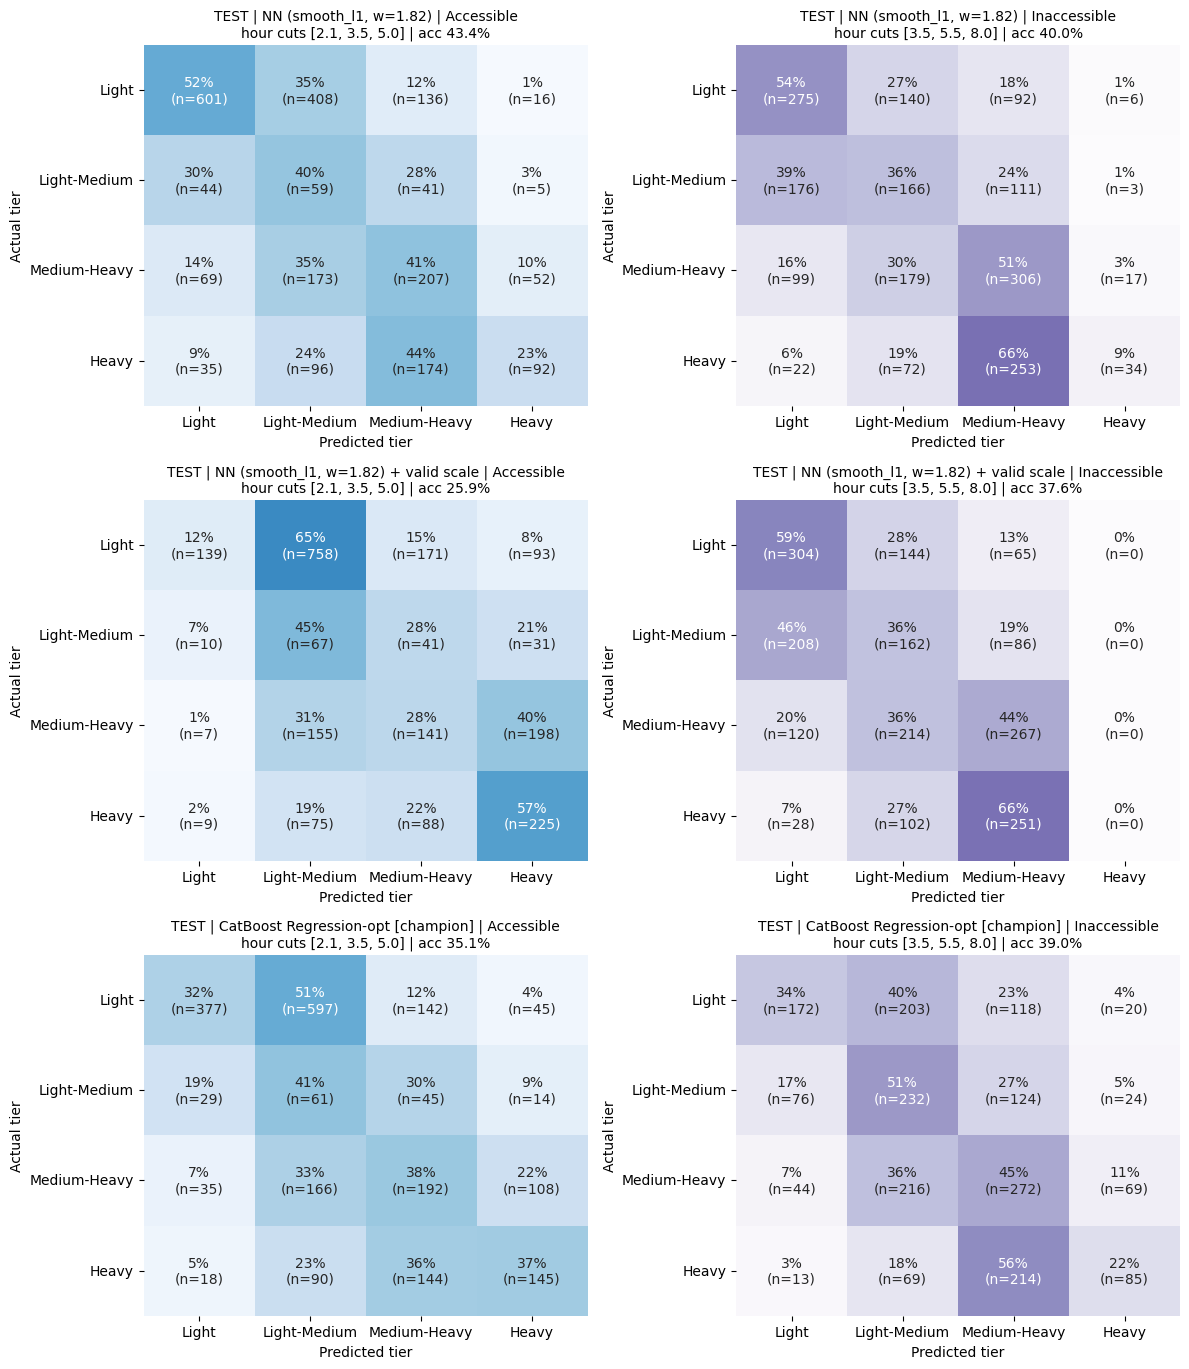

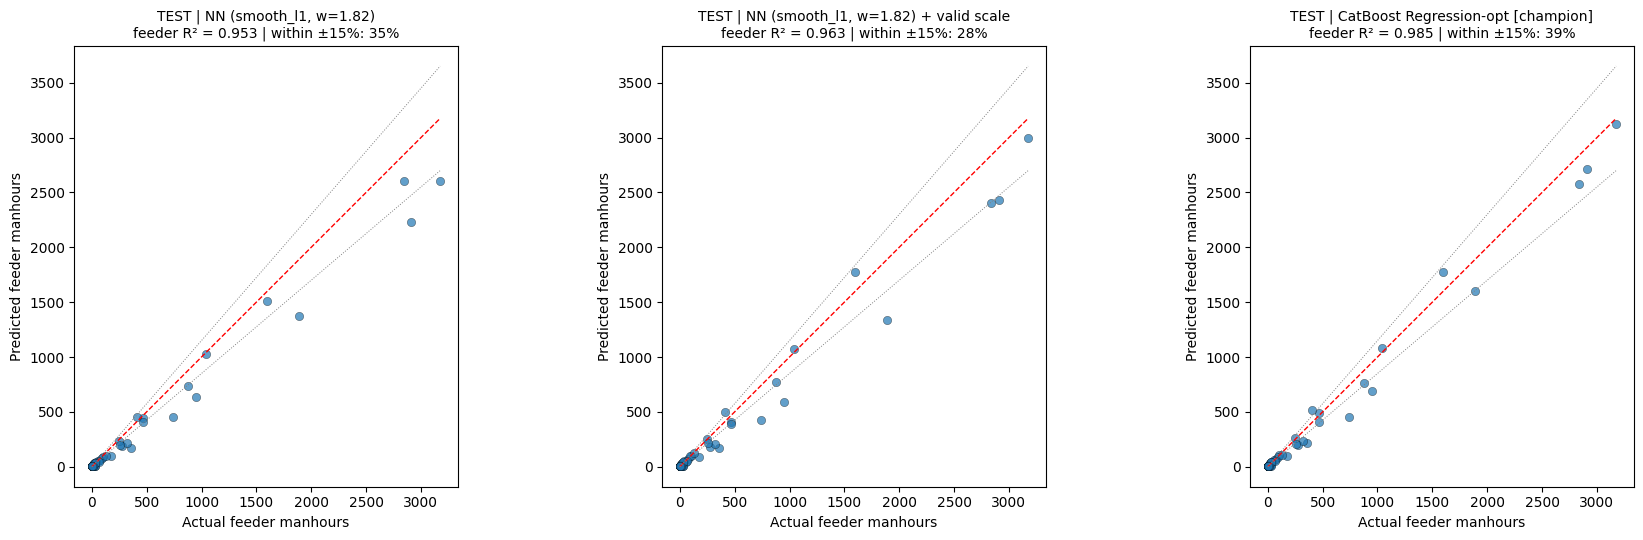


TEST - NN errors by impactful issue


,n,MAE,Actual_Mean,Predicted_Mean
issue,,,,
Heavy Contact,145,3.908,7.583,4.699
Busy Area,79,3.143,6.499,4.699
Long Brush Drag,284,3.135,6.954,5.438
Weather,44,2.469,6.068,4.171
Other,41,2.406,5.268,3.699
Access Issues,104,2.378,5.990,4.664
NaN,3312,1.908,4.456,3.748
Infrastructure,15,1.278,3.040,2.625
Flagging,135,1.263,2.746,3.132


In [7]:
seeds = [SEED + i for i in range(NN_CFG["n_seeds_final"])]
dev_nets = fit_ensemble(BEST_SPEC, ("train",), seeds, verbose=not FAST)
valid_out = predict_ensemble(dev_nets, "valid")
test_out = predict_ensemble(dev_nets, "test")
vp.show(pd.DataFrame([h for n in dev_nets for h in n.history]), "Training history (early-stopping slice of Train)")

# L1-type losses target the median -> feeder sums tend to run low. Scale fit on Validation only.
NN_SCALE = {seg: float(FULL_Y["valid"][FULL_META["valid"]["inaccessible"].eq(f).to_numpy()].sum()
                       / valid_out["point"][FULL_META["valid"]["inaccessible"].eq(f).to_numpy()].sum())
            for seg, f in vp.SEGMENTS.items()}
print("Validation-fit scale factors:", {k: round(v, 4) for k, v in NN_SCALE.items()})


def scale_segments(pred, meta):
    out = pred.copy()
    for seg, f in vp.SEGMENTS.items():
        m = meta["inaccessible"].eq(f).to_numpy()
        out[m] = out[m] * NN_SCALE[seg]
    return out


NN_NAME = f"NN ({BEST_SPEC['loss']}, w={BEST_SPEC['weight_strength']:.2f})"
vp.show(pd.DataFrame([vp.evaluate_combined(NN_NAME, FULL_Y["valid"], valid_out["point"], FULL_META["valid"], HOUR_CUTS)])
        .set_index("Model")[vp.COMPARE_COLS], "VALIDATION (selection split)")

test_meta, y_test, X_test = FULL_META["test"], FULL_Y["test"], FULL_X["test"]
test_preds = {NN_NAME: test_out["point"], f"{NN_NAME} + valid scale": scale_segments(test_out["point"], test_meta)}

DEVICE_MAP = vp.load_protective_device_map(os.path.join(INPUT_DIR, "span_data.pkl"))

test_meta = vp.attach_device_columns(test_meta, DEVICE_MAP)
for device_col in vp.PROTECTIVE_DEVICE_COLS:
    vp.protective_device_scatter(
        {NN_NAME: test_out["point"]}, y_test, test_meta, device_col,
        "NN TEST", fig(f"nn_test_{device_col}_scatter.png"), SHOW_PLOTS)

cb_quantiles = None
champion = DECISIONS["champion"]
if os.path.exists(CATBOOST_TEST_PREDS):
    cb = pd.read_csv(CATBOOST_TEST_PREDS, index_col=0)
    cb.index = cb.index.astype(X_test.index.dtype)
    cb = cb.reindex(X_test.index)
    if cb.isna().any().any():
        print("WARNING: CatBoost Test predictions do not cover all Test rows - skipping comparison.")
    else:
        assert np.allclose(cb["actual"], y_test), "CatBoost file targets differ from Test targets"
        for col in [c for c in cb.columns if c != "actual"]:
            test_preds[f"CatBoost {col}" + (" [champion]" if col == champion else "")] = cb[col]
        if os.path.exists(CATBOOST_TEST_QUANTILES):
            cb_quantiles = pd.read_csv(CATBOOST_TEST_QUANTILES, index_col=0)
            cb_quantiles.index = cb_quantiles.index.astype(X_test.index.dtype)
            cb_quantiles = cb_quantiles.reindex(X_test.index)

test_table = pd.DataFrame([vp.evaluate_combined(n, y_test, p, test_meta, HOUR_CUTS)
                           for n, p in test_preds.items()]).set_index("Model")
vp.show(test_table[vp.COMPARE_COLS].sort_values("Feeder_WAPE"), "TEST - NN vs CatBoost (identical rows)")
print(f"NN Test 80% interval coverage: {((y_test >= test_out['p10']) & (y_test <= test_out['p90'])).mean():.3f} "
      f"| mean width {(test_out['p90'] - test_out['p10']).mean():.2f} h")

highlight = {k: v for k, v in test_preds.items() if k.startswith("NN") or "[champion]" in k}
vp.confusion_grid(highlight, y_test, test_meta, HOUR_CUTS, "TEST", fig("nn_test_hour_tier_confusion.png"), SHOW_PLOTS)
vp.feeder_scatter(highlight, y_test, test_meta, "TEST", fig("nn_test_feeder_scatter.png"), SHOW_PLOTS)
if "impactful_issues" in test_meta.columns:
    vp.show(vp.issue_table(y_test, test_out["point"], test_meta["impactful_issues"]), "TEST - NN errors by impactful issue", 3)

In [8]:
print(test_meta.columns)

Index(['feeder', 'inaccessible', 'impactful_issues', 'veg_tier', 'bay',
       'area_class__dominant_land_cover_general', 'area_class__area_lc',
       'area_class__area_lcxfm', 'area_class__area_xfmr', 'protective_device',
       'major_protective_device'],
      dtype='object')


## 7. 24-class risk tables (Test) — NN vs CatBoost champion
Class = accessibility × area × bid-time tier (hours: tier of the prediction; volume: LiDAR volume tier).
P10 / P90 come from each model's own quantile outputs.


NN TEST - hours tiers (PRIMARY)


N  Mean_Hours  Median_Hours  \
Accessibility Area     Veg_Tier                                      
Accessible    Urban    Light         134        2.18           2.0   
                       Light-Medium   84        3.05           3.0   
                       Medium-Heavy   28        5.55           5.5   
                       Heavy           0         NaN           NaN   
              Suburban Light         282        1.99           2.0   
                       Light-Medium  390        3.15           2.0   
                       Medium-Heavy  245        4.34           4.0   
                       Heavy          46        7.51           6.0   
              Rural    Light         333        2.48           2.0   
                       Light-Medium  262        3.54           2.0   
                       Medium-Heavy  285        5.01           4.0   
                       Heavy         119        6.31           6.0   
Inaccessible  Urban    Light          62        3.88           4.0   
                       Light-Medium   33        5.21           5.0   
                       Medium-Heavy   71        7.18           6.0   
                       Heavy          14        9.29          10.0   
              Suburban Light         290        4.15           4.0   
                       Light-Medium  390        5.47           4.0   
                       Medium-Heavy  550        8.27           8.0   
                       Heavy          41       10.97          10.0   
              Rural    Light         220        3.38           2.0   
                       Light-Medium  134        5.71           4.0   
                       Medium-Heavy  141        7.77           6.0   
                       Heavy           5        8.20           8.0   

                                     Mean_CI95_Low  Mean_CI95_High   P10  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light                  2.03            2.34  0.92   
                       Light-Medium           2.73            3.38  1.31   
                       Medium-Heavy           4.50            6.68  1.95   
                       Heavy                   NaN             NaN   NaN   
              Suburban Light                  1.81            2.19  0.89   
                       Light-Medium           2.91            3.43  1.33   
                       Medium-Heavy           3.98            4.72  2.03   
                       Heavy                  5.83            9.62  2.51   
              Rural    Light                  2.25            2.72  0.88   
                       Light-Medium           3.18            3.96  1.33   
                       Medium-Heavy           4.54            5.51  2.15   
                       Heavy                  5.47            7.34  2.60   
Inaccessible  Urban    Light                  3.33            4.46  1.17   
                       Light-Medium           4.59            5.88  1.52   
                       Medium-Heavy           6.48            7.93  1.99   
                       Heavy                  8.71            9.71  2.40   
              Suburban Light                  3.83            4.52  1.16   
                       Light-Medium           5.15            5.80  1.45   
                       Medium-Heavy           7.87            8.69  1.92   
                       Heavy                  8.75           13.23  2.41   
              Rural    Light                  3.07            3.72  1.13   
                       Light-Medium           5.02            6.45  1.44   
                       Medium-Heavy           6.96            8.65  1.85   
                       Heavy                  5.20           11.20  2.37   

                                      P50    P90  Pred_Width   MAE  Bias  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light         1.85   3.53        2.61  0.63 -0.33   
             

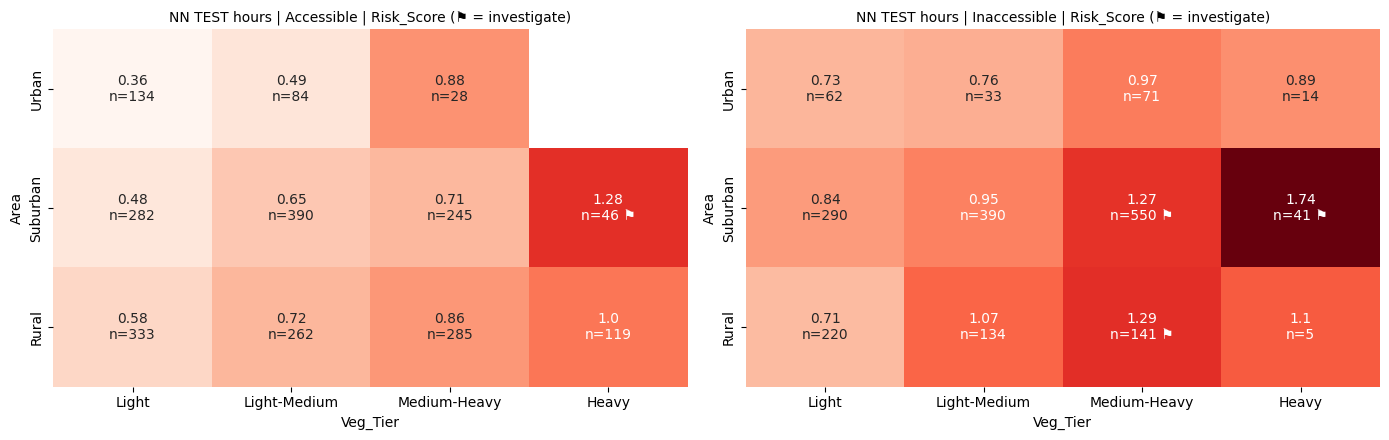


NN TEST - volume tiers


N  Mean_Hours  Median_Hours  \
Accessibility Area     Veg_Tier                                      
Accessible    Urban    Light         109        2.37          2.00   
                       Light-Medium   81        2.76          2.00   
                       Medium-Heavy   50        3.93          3.50   
                       Heavy           6        4.17          4.00   
              Suburban Light         213        2.43          2.00   
                       Light-Medium  210        2.81          2.00   
                       Medium-Heavy  203        3.08          2.00   
                       Heavy         337        4.36          4.00   
              Rural    Light         282        3.12          2.00   
                       Light-Medium  223        3.56          2.00   
                       Medium-Heavy  190        3.90          4.00   
                       Heavy         304        4.99          4.00   
Inaccessible  Urban    Light          35        3.53          4.00   
                       Light-Medium   54        5.36          4.00   
                       Medium-Heavy   61        6.80          6.00   
                       Heavy          30        7.50          7.00   
              Suburban Light         176        4.05          4.00   
                       Light-Medium  223        5.66          4.00   
                       Medium-Heavy  324        6.13          6.00   
                       Heavy         548        7.98          7.25   
              Rural    Light         101        3.55          2.00   
                       Light-Medium  106        4.36          4.00   
                       Medium-Heavy  104        4.31          4.00   
                       Heavy         189        7.28          6.00   

                                     Mean_CI95_Low  Mean_CI95_High   P10  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light                  2.12            2.66  1.02   
                       Light-Medium           2.43            3.14  1.16   
                       Medium-Heavy           3.35            4.53  1.43   
                       Heavy                  2.33            6.17  1.78   
              Suburban Light                  2.13            2.77  1.02   
                       Light-Medium           2.54            3.09  1.31   
                       Medium-Heavy           2.72            3.52  1.44   
                       Heavy                  4.00            4.75  1.78   
              Rural    Light                  2.77            3.53  1.07   
                       Light-Medium           3.14            4.15  1.45   
                       Medium-Heavy           3.50            4.32  1.61   
                       Heavy                  4.52            5.51  2.08   
Inaccessible  Urban    Light                  2.93            4.17  1.31   
                       Light-Medium           4.66            6.15  1.52   
                       Medium-Heavy           6.07            7.54  1.80   
                       Heavy                  6.53            8.63  1.99   
              Suburban Light                  3.67            4.43  1.31   
                       Light-Medium           5.18            6.18  1.51   
                       Medium-Heavy           5.73            6.53  1.59   
                       Heavy                  7.55            8.42  1.78   
              Rural    Light                  3.03            4.14  1.20   
                       Light-Medium           3.79            4.94  1.28   
                       Medium-Heavy           3.76            4.90  1.35   
                       Heavy                  6.54            8.07  1.67   

                                      P50    P90  Pred_Width   MAE  Bias  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light         2.04   3.90        2.88  0.81 -0.33   
             

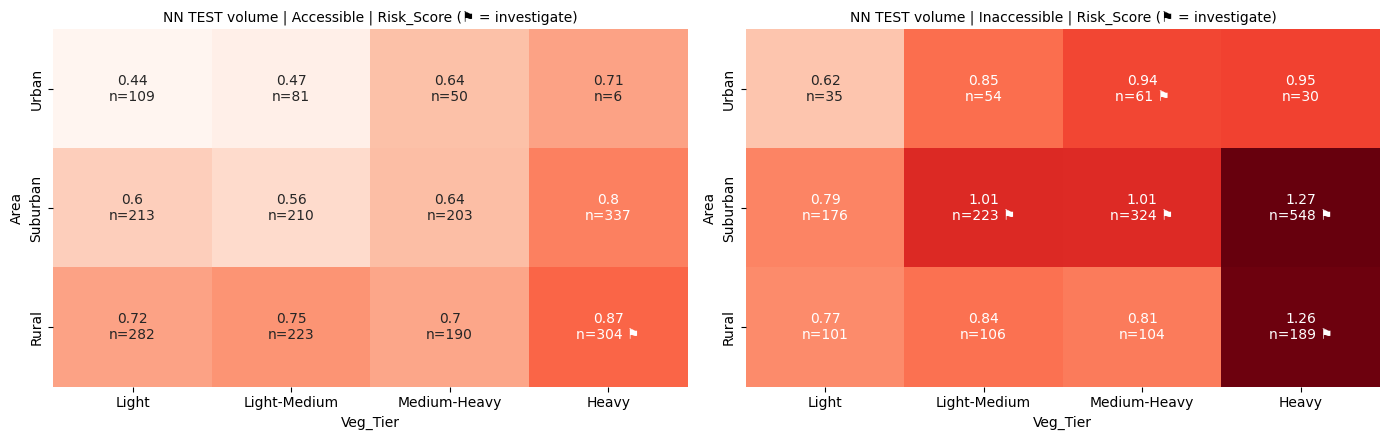


NN TEST - hour vs volume tier scheme


,Eta2_24class,Weighted_CV,Weighted_Abs_Class_Bias,Weighted_Risk,Max_Risk,Share_Spans_Flagged,Classes_Investigate,Classes_Low_N,Empty_Classes,Min_N
Scheme,,,,,,,,,,
hours,0.2704,0.7056,0.8599,0.8405,1.7418,0.1871,4,3,1,5
volume,0.1952,0.7649,0.8599,0.8580,1.2720,0.3965,6,1,0,6



NN TEST - classes to investigate


N  Mean_Hours    CV  Pred_Width  \
Scheme Accessibility Area     Veg_Tier                                          
hours  Inaccessible  Suburban Heavy          41       10.97  0.65       12.73   
                     Rural    Medium-Heavy  141        7.77  0.67       11.50   
       Accessible    Suburban Heavy          46        7.51  0.87        7.51   
       Inaccessible  Suburban Medium-Heavy  550        8.27  0.58       11.61   
volume Inaccessible  Suburban Heavy         548        7.98  0.64       10.57   
                     Rural    Heavy         189        7.28  0.71       10.14   
                     Suburban Light-Medium  223        5.66  0.71        8.27   
                              Medium-Heavy  324        6.13  0.60        9.05   
                     Urban    Medium-Heavy   61        6.80  0.43        9.86   
       Accessible    Rural    Heavy         304        4.99  0.88        5.93   

                                             MAE  Bias  Risk_Score  \
Scheme Accessibility Area     Veg_Tier                               
hours  Inaccessible  Suburban Heavy         5.65 -2.83        1.74   
                     Rural    Medium-Heavy  3.70 -1.07        1.29   
       Accessible    Suburban Heavy         3.79 -2.25        1.28   
       Inaccessible  Suburban Medium-Heavy  3.42 -1.43        1.27   
volume Inaccessible  Suburban Heavy         3.40 -1.86        1.27   
                     Rural    Heavy         3.56 -1.50        1.26   
                     Suburban Light-Medium  2.62 -1.05        1.01   
                              Medium-Heavy  2.57 -1.03        1.01   
                     Urban    Medium-Heavy  2.11 -0.96        0.94   
       Accessible    Rural    Heavy         2.13 -0.77        0.87   

                                                Flagged_On  
Scheme Accessibility Area     Veg_Tier                      
hours  Inaccessible  Suburban Heavy         Pred_Width,MAE  
                     Rural    Medium-Heavy  Pred_Width,MAE  
       Accessible    Suburban Heavy                 CV,MAE  
       Inaccessible  Suburban Medium-Heavy  Pred_Width,MAE  
volume Inaccessible  Suburban Heavy         Pred_Width,MAE  
                     Rural    Heavy         Pred_Width,MAE  
                     Suburban Light-Medium  Pred_Width,MAE  
                              Medium-Heavy  Pred_Width,MAE  
                     Urban    Medium-Heavy  Pred_Width,MAE  
       Accessible    Rural    Heavy                 CV,MAE


CatBoost TEST - hours tiers (PRIMARY)


N  Mean_Hours  Median_Hours  \
Accessibility Area     Veg_Tier                                      
Accessible    Urban    Light          87        2.17           2.0   
                       Light-Medium  128        2.76           2.0   
                       Medium-Heavy   26        5.06           4.0   
                       Heavy           5        6.00           8.0   
              Suburban Light         179        1.81           1.5   
                       Light-Medium  436        2.82           2.0   
                       Medium-Heavy  247        4.18           4.0   
                       Heavy         101        6.07           5.0   
              Rural    Light         193        2.38           2.0   
                       Light-Medium  350        3.05           2.0   
                       Medium-Heavy  250        4.75           4.0   
                       Heavy         206        5.91           4.0   
Inaccessible  Urban    Light          30        2.98           2.0   
                       Light-Medium   63        4.89           4.0   
                       Medium-Heavy   76        7.34           6.0   
                       Heavy          11        8.82           8.0   
              Suburban Light         181        3.96           3.0   
                       Light-Medium  506        5.31           4.0   
                       Medium-Heavy  468        7.88           8.0   
                       Heavy         116       10.70          10.0   
              Rural    Light          94        2.99           2.0   
                       Light-Medium  151        4.47           4.0   
                       Medium-Heavy  184        6.27           4.0   
                       Heavy          71        7.52           6.0   

                                     Mean_CI95_Low  Mean_CI95_High   P10  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light                  1.96            2.38  1.01   
                       Light-Medium           2.52            3.02  1.19   
                       Medium-Heavy           4.02            6.21  1.90   
                       Heavy                  3.60            8.00  2.13   
              Suburban Light                  1.61            2.05  0.86   
                       Light-Medium           2.61            3.05  1.25   
                       Medium-Heavy           3.83            4.60  1.90   
                       Heavy                  5.25            7.00  2.40   
              Rural    Light                  2.08            2.74  0.83   
                       Light-Medium           2.83            3.29  1.25   
                       Medium-Heavy           4.32            5.25  1.98   
                       Heavy                  5.23            6.69  2.57   
Inaccessible  Urban    Light                  2.43            3.55  1.22   
                       Light-Medium           4.39            5.44  1.49   
                       Medium-Heavy           6.66            8.08  1.66   
                       Heavy                  8.27            9.36  1.78   
              Suburban Light                  3.51            4.47  1.21   
                       Light-Medium           5.05            5.57  1.55   
                       Medium-Heavy           7.49            8.30  1.66   
                       Heavy                  9.50           11.93  2.09   
              Rural    Light                  2.60            3.40  1.18   
                       Light-Medium           3.98            5.01  1.48   
                       Medium-Heavy           5.55            7.03  1.65   
                       Heavy                  6.52            8.55  2.09   

                                      P50    P90  Pred_Width   MAE  Bias  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light         2.00   3.69        2.68  0.64 -0.12   
             

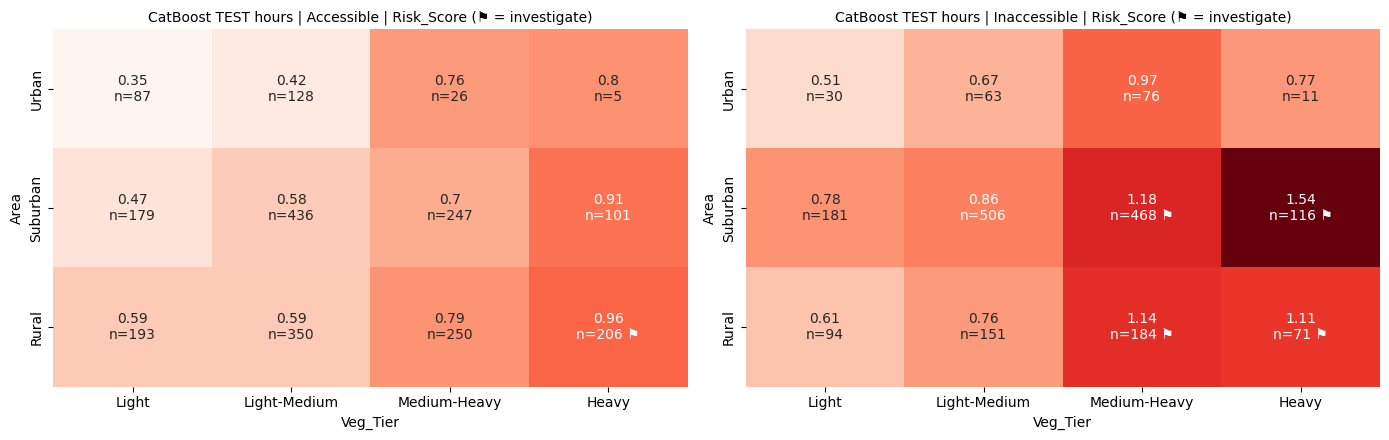


CatBoost TEST - volume tiers


N  Mean_Hours  Median_Hours  \
Accessibility Area     Veg_Tier                                      
Accessible    Urban    Light         109        2.37          2.00   
                       Light-Medium   81        2.76          2.00   
                       Medium-Heavy   50        3.93          3.50   
                       Heavy           6        4.17          4.00   
              Suburban Light         213        2.43          2.00   
                       Light-Medium  210        2.81          2.00   
                       Medium-Heavy  203        3.08          2.00   
                       Heavy         337        4.36          4.00   
              Rural    Light         282        3.12          2.00   
                       Light-Medium  223        3.56          2.00   
                       Medium-Heavy  190        3.90          4.00   
                       Heavy         304        4.99          4.00   
Inaccessible  Urban    Light          35        3.53          4.00   
                       Light-Medium   54        5.36          4.00   
                       Medium-Heavy   61        6.80          6.00   
                       Heavy          30        7.50          7.00   
              Suburban Light         176        4.05          4.00   
                       Light-Medium  223        5.66          4.00   
                       Medium-Heavy  324        6.13          6.00   
                       Heavy         548        7.98          7.25   
              Rural    Light         101        3.55          2.00   
                       Light-Medium  106        4.36          4.00   
                       Medium-Heavy  104        4.31          4.00   
                       Heavy         189        7.28          6.00   

                                     Mean_CI95_Low  Mean_CI95_High   P10  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light                  2.12            2.66  1.07   
                       Light-Medium           2.43            3.14  1.22   
                       Medium-Heavy           3.35            4.53  1.47   
                       Heavy                  2.33            6.17  1.85   
              Suburban Light                  2.13            2.77  1.05   
                       Light-Medium           2.54            3.09  1.32   
                       Medium-Heavy           2.72            3.52  1.45   
                       Heavy                  4.00            4.75  1.83   
              Rural    Light                  2.77            3.53  1.13   
                       Light-Medium           3.14            4.15  1.49   
                       Medium-Heavy           3.50            4.32  1.63   
                       Heavy                  4.52            5.51  2.18   
Inaccessible  Urban    Light                  2.93            4.17  1.34   
                       Light-Medium           4.66            6.15  1.53   
                       Medium-Heavy           6.07            7.54  1.59   
                       Heavy                  6.53            8.63  1.65   
              Suburban Light                  3.67            4.43  1.34   
                       Light-Medium           5.18            6.18  1.51   
                       Medium-Heavy           5.73            6.53  1.59   
                       Heavy                  7.55            8.42  1.70   
              Rural    Light                  3.03            4.14  1.32   
                       Light-Medium           3.79            4.94  1.42   
                       Medium-Heavy           3.76            4.90  1.59   
                       Heavy                  6.54            8.07  1.79   

                                      P50    P90  Pred_Width   MAE  Bias  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light         2.10   3.98        2.91  0.80 -0.07   
             

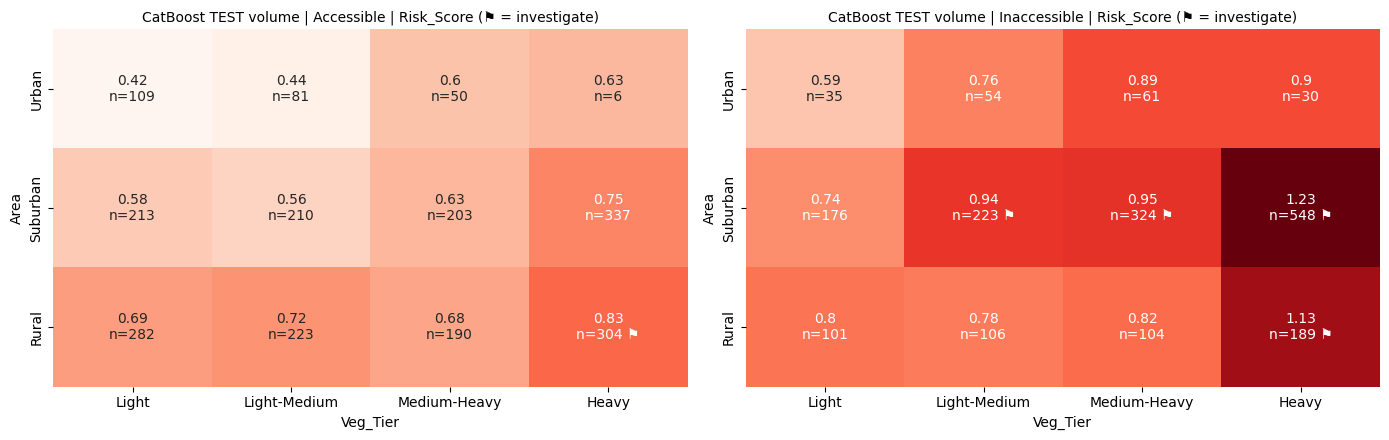


CatBoost TEST - hour vs volume tier scheme


,Eta2_24class,Weighted_CV,Weighted_Abs_Class_Bias,Weighted_Risk,Max_Risk,Share_Spans_Flagged,Classes_Investigate,Classes_Low_N,Empty_Classes,Min_N
Scheme,,,,,,,,,,
hours,0.2628,0.7103,0.5177,0.8022,1.5369,0.2513,5,3,0,5
volume,0.1952,0.7649,0.5149,0.8182,1.2312,0.3818,5,1,0,6



CatBoost TEST - classes to investigate


N  Mean_Hours    CV  Pred_Width  \
Scheme Accessibility Area     Veg_Tier                                          
hours  Inaccessible  Suburban Heavy         116       10.70  0.61       13.84   
                              Medium-Heavy  468        7.88  0.57       10.88   
                     Rural    Medium-Heavy  184        6.27  0.83        9.32   
                              Heavy          71        7.52  0.56       11.19   
       Accessible    Rural    Heavy         206        5.91  0.91        7.52   
volume Inaccessible  Suburban Heavy         548        7.98  0.64       10.57   
                     Rural    Heavy         189        7.28  0.71        9.92   
                     Suburban Medium-Heavy  324        6.13  0.60        8.62   
                              Light-Medium  223        5.66  0.71        7.88   
       Accessible    Rural    Heavy         304        4.99  0.88        6.21   

                                             MAE  Bias  Risk_Score  \
Scheme Accessibility Area     Veg_Tier                               
hours  Inaccessible  Suburban Heavy         4.92 -1.41        1.54   
                              Medium-Heavy  3.25 -1.35        1.18   
                     Rural    Medium-Heavy  3.96  0.33        1.14   
                              Heavy         3.58  1.74        1.11   
       Accessible    Rural    Heavy         2.89  0.25        0.96   
volume Inaccessible  Suburban Heavy         3.40 -1.61        1.23   
                     Rural    Heavy         3.80 -0.13        1.13   
                     Suburban Medium-Heavy  2.60 -0.74        0.95   
                              Light-Medium  2.48 -0.76        0.94   
       Accessible    Rural    Heavy         2.33 -0.05        0.83   

                                                   Flagged_On  
Scheme Accessibility Area     Veg_Tier                         
hours  Inaccessible  Suburban Heavy            Pred_Width,MAE  
                              Medium-Heavy     Pred_Width,MAE  
                     Rural    Medium-Heavy  Pred_Width,CV,MAE  
                              Heavy            Pred_Width,MAE  
       Accessible    Rural    Heavy                    CV,MAE  
volume Inaccessible  Suburban Heavy            Pred_Width,MAE  
                     Rural    Heavy            Pred_Width,MAE  
                     Suburban Medium-Heavy     Pred_Width,MAE  
                              Light-Medium     Pred_Width,MAE  
       Accessible    Rural    Heavy                    CV,MAE


Scheme summary: NN vs CatBoost


Eta2_24class  Weighted_CV  \
                        Scheme                              
NN                      hours         0.2704       0.7056   
                        volume        0.1952       0.7649   
CatBoost Regression-opt hours         0.2628       0.7103   
                        volume        0.1952       0.7649   

                                Weighted_Abs_Class_Bias  Weighted_Risk  \
                        Scheme                                           
NN                      hours                    0.8599         0.8405   
                        volume                   0.8599         0.8580   
CatBoost Regression-opt hours                    0.5177         0.8022   
                        volume                   0.5149         0.8182   

                                Max_Risk  Share_Spans_Flagged  \
                        Scheme                                  
NN                      hours     1.7418               0.1871   
                        volume    1.2720               0.3965   
CatBoost Regression-opt hours     1.5369               0.2513   
                        volume    1.2312               0.3818   

                                Classes_Investigate  Classes_Low_N  \
                        Scheme                                       
NN                      hours                     4              3   
                        volume                    6              1   
CatBoost Regression-opt hours                     5              3   
                        volume                    5              1   

                                Empty_Classes  Min_N  
                        Scheme                        
NN                      hours               1      5  
                        volume              0      6  
CatBoost Regression-opt hours               0      5  
                        volume              0      6


hours tiers - NN vs CatBoost by class (Test)


NN_Risk  CB_Risk  NN_Width  CB_Width  \
Accessibility Area     Veg_Tier                                             
Accessible    Urban    Light            0.36     0.35      2.61      2.68   
                       Light-Medium     0.49     0.42      3.62      3.16   
                       Medium-Heavy     0.88     0.76      6.07      5.17   
                       Heavy             NaN     0.80       NaN      7.24   
              Suburban Light            0.48     0.47      2.62      2.69   
                       Light-Medium     0.65     0.58      3.86      3.38   
                       Medium-Heavy     0.71     0.70      6.01      5.61   
                       Heavy            1.28     0.91      7.51      7.52   
              Rural    Light            0.58     0.59      2.52      2.63   
                       Light-Medium     0.72     0.59      3.69      3.42   
                       Medium-Heavy     0.86     0.79      6.11      5.95   
                       Heavy            1.00     0.96      7.48      7.52   
Inaccessible  Urban    Light            0.73     0.51      4.93      4.17   
                       Light-Medium     0.76     0.67      8.42      7.08   
                       Medium-Heavy     0.97     0.97     11.65     10.54   
                       Heavy            0.89     0.77     12.63     12.83   
              Suburban Light            0.84     0.78      5.19      4.81   
                       Light-Medium     0.95     0.86      8.47      7.64   
                       Medium-Heavy     1.27     1.18     11.61     10.88   
                       Heavy            1.74     1.54     12.73     13.84   
              Rural    Light            0.71     0.61      4.60      4.97   
                       Light-Medium     1.07     0.76      8.42      6.86   
                       Medium-Heavy     1.29     1.14     11.50      9.32   
                       Heavy            1.10     1.11     12.76     11.19   

                                     NN_Cov80  CB_Cov80  NN_MAE  CB_MAE  \
Accessibility Area     Veg_Tier                                           
Accessible    Urban    Light             0.87      0.82    0.63    0.64   
                       Light-Medium      0.89      0.86    1.05    0.89   
                       Medium-Heavy      0.79      0.73    2.51    2.15   
                       Heavy              NaN      0.80     NaN    2.73   
              Suburban Light             0.79      0.75    0.86    0.89   
                       Light-Medium      0.77      0.76    1.51    1.39   
                       Medium-Heavy      0.76      0.79    1.84    1.81   
                       Heavy             0.74      0.73    3.79    2.82   
              Rural    Light             0.75      0.79    1.13    1.08   
                       Light-Medium      0.77      0.77    1.70    1.48   
                       Medium-Heavy      0.73      0.80    2.17    2.01   
                       Heavy             0.84      0.79    2.57    2.89   
Inaccessible  Urban    Light             0.82      0.90    1.65    1.31   
                       Light-Medium      0.97      0.95    1.59    1.45   
                       Medium-Heavy      0.94      0.92    2.26    2.36   
                       Heavy             1.00      1.00    1.23    0.97   
              Suburban Light             0.75      0.75    2.05    1.97   
                       Light-Medium      0.88      0.85    2.37    2.31   
                       Medium-Heavy      0.85      0.84    3.42    3.25   
                       Heavy             0.66      0.74    5.65    4.92   
              Rural    Light             0.81      0.82    1.55    1.22   
                       Light-Medium      0.78      0.88    2.86    1.98   
                       Medium-Heavy      0.82      0.73    3.70    3.96   
                       Heavy             1.00      0.86    2.95    3.58   

                                     Both_Investigate  
Accessibility Area     Veg_


volume tiers - NN vs CatBoost by class (Test)


NN_Risk  CB_Risk  NN_Width  CB_Width  \
Accessibility Area     Veg_Tier                                             
Accessible    Urban    Light            0.44     0.42      2.88      2.91   
                       Light-Medium     0.47     0.44      3.36      3.38   
                       Medium-Heavy     0.64     0.60      4.13      3.75   
                       Heavy            0.71     0.63      5.17      5.01   
              Suburban Light            0.60     0.58      3.02      3.23   
                       Light-Medium     0.56     0.56      3.91      3.86   
                       Medium-Heavy     0.64     0.63      4.20      4.12   
                       Heavy            0.80     0.75      5.18      5.24   
              Rural    Light            0.72     0.69      3.01      3.39   
                       Light-Medium     0.75     0.72      4.14      4.41   
                       Medium-Heavy     0.70     0.68      4.55      4.82   
                       Heavy            0.87     0.83      5.93      6.21   
Inaccessible  Urban    Light            0.62     0.59      6.03      6.01   
                       Light-Medium     0.85     0.76      7.96      7.64   
                       Medium-Heavy     0.94     0.89      9.86      9.25   
                       Heavy            0.95     0.90     11.51     10.86   
              Suburban Light            0.79     0.74      6.50      6.19   
                       Light-Medium     1.01     0.94      8.27      7.88   
                       Medium-Heavy     1.01     0.95      9.05      8.62   
                       Heavy            1.27     1.23     10.57     10.57   
              Rural    Light            0.77     0.80      5.21      6.38   
                       Light-Medium     0.84     0.78      6.07      6.73   
                       Medium-Heavy     0.81     0.82      7.11      7.50   
                       Heavy            1.26     1.13     10.14      9.92   

                                     NN_Cov80  CB_Cov80  NN_MAE  CB_MAE  \
Accessibility Area     Veg_Tier                                           
Accessible    Urban    Light             0.89      0.83    0.81    0.80   
                       Light-Medium      0.89      0.86    0.84    0.80   
                       Medium-Heavy      0.80      0.78    1.52    1.55   
                       Heavy             0.83      0.83    1.93    1.57   
              Suburban Light             0.77      0.74    1.17    1.21   
                       Light-Medium      0.77      0.74    1.26    1.33   
                       Medium-Heavy      0.83      0.81    1.31    1.40   
                       Heavy             0.74      0.77    2.01    1.99   
              Rural    Light             0.77      0.79    1.47    1.48   
                       Light-Medium      0.78      0.80    1.57    1.60   
                       Medium-Heavy      0.72      0.76    1.76    1.81   
                       Heavy             0.77      0.79    2.13    2.33   
Inaccessible  Urban    Light             0.89      0.94    1.33    1.32   
                       Light-Medium      0.89      0.93    1.87    1.75   
                       Medium-Heavy      0.92      0.92    2.11    2.14   
                       Heavy             0.97      0.97    1.87    1.63   
              Suburban Light             0.81      0.82    2.03    2.02   
                       Light-Medium      0.81      0.82    2.62    2.48   
                       Medium-Heavy      0.85      0.84    2.57    2.60   
                       Heavy             0.84      0.82    3.40    3.40   
              Rural    Light             0.83      0.85    1.77    2.17   
                       Light-Medium      0.77      0.81    2.00    2.16   
                       Medium-Heavy      0.84      0.84    1.89    2.20   
                       Heavy             0.80      0.78    3.56    3.80   

                                     Both_Investigate  
Accessibility Area     Veg_

In [9]:
AREA_CLASS_COL = f"area_class__{CHOSEN_AREA_COL}"

def risk_tables(label, X, y, meta, point, p10, p50, p90):
    tables, keys = {}, {}
    for n, scheme in SCHEMES.items():
        lab = scheme.bid_labels(X, point, meta)
        tables[n] = vp.class_risk_table(y, point, p10, p50, p90, meta, AREA_CLASS_COL, lab)
        keys[n] = vp.class_keys(meta, AREA_CLASS_COL, lab)
        vp.show(tables[n][vp.RISK_TABLE_COLS + ["Flagged_On"]],
                f"{label} - {n} tiers" + (" (PRIMARY)" if n == PRIMARY else ""), 2, max_rows=30)
        vp.plot_risk_heatmap(tables[n], f"{label} {n}", "Risk_Score",
                             fig(f"{label.lower().replace(' ', '_')}_{n}_risk.png"), SHOW_PLOTS)
    in_area = meta[AREA_CLASS_COL].isin(vp.AREA_CLASSES).to_numpy()
    summary = vp.scheme_summary(tables, np.asarray(y)[in_area], {n: v[in_area] for n, v in keys.items()})
    investigate = pd.concat({n: t[t["Investigate"]].sort_values("Risk_Score", ascending=False)
                             [["N", "Mean_Hours", "CV", "Pred_Width", "MAE", "Bias", "Risk_Score", "Flagged_On"]]
                             for n, t in tables.items()}, names=["Scheme"])
    vp.show(summary, f"{label} - hour vs volume tier scheme")
    vp.show(investigate, f"{label} - classes to investigate", 2)
    return tables, summary, investigate


NN_TEST_RISK, NN_TEST_SUMMARY, NN_TEST_INVESTIGATE = risk_tables(
    "NN TEST", X_test, y_test, test_meta, test_out["point"], test_out["p10"], test_out["point"], test_out["p90"])

if cb_quantiles is not None and champion in cb.columns:
    CB_TEST_RISK, CB_TEST_SUMMARY, _ = risk_tables(
        "CatBoost TEST", X_test, y_test, test_meta, cb[champion], cb_quantiles["q10"], cb_quantiles["q50"],
        cb_quantiles["q90"])
    vp.show(pd.concat({"NN": NN_TEST_SUMMARY, f"CatBoost {champion}": CB_TEST_SUMMARY}), "Scheme summary: NN vs CatBoost")
    for n in SCHEMES:
        vp.show(pd.DataFrame({"NN_Risk": NN_TEST_RISK[n]["Risk_Score"], "CB_Risk": CB_TEST_RISK[n]["Risk_Score"],
                              "NN_Width": NN_TEST_RISK[n]["Pred_Width"], "CB_Width": CB_TEST_RISK[n]["Pred_Width"],
                              "NN_Cov80": NN_TEST_RISK[n]["Coverage_80"], "CB_Cov80": CB_TEST_RISK[n]["Coverage_80"],
                              "NN_MAE": NN_TEST_RISK[n]["MAE"], "CB_MAE": CB_TEST_RISK[n]["MAE"],
                              "Both_Investigate": NN_TEST_RISK[n]["Investigate"] & CB_TEST_RISK[n]["Investigate"]}),
                f"{n} tiers - NN vs CatBoost by class (Test)", 2, max_rows=30)

## 8. Grouped permutation importance (Validation)

In [10]:
if NN_CFG["run_group_permutation"]:
    rng = np.random.default_rng(SEED)
    groups = {k: [c for c in v if c in FEATURES] for k, v in MANIFEST["feature_groups"].items()}
    groups["inaccessible (input only)"] = ["inaccessible"] if "inaccessible" in FEATURES else []
    y_v, f_v = FULL_Y["valid"].to_numpy(), FULL_META["valid"]["feeder"].to_numpy()
    base_mae = float(np.mean(np.abs(y_v - valid_out["point"])))
    base_wape = vp.feeder_wape(y_v, valid_out["point"].to_numpy(), f_v)
    rows = []
    for name, cols in groups.items():
        if not cols:
            continue
        Xp = FULL_X["valid"].copy()
        Xp[cols] = Xp[cols].iloc[rng.permutation(len(Xp))].to_numpy()   # permute the group jointly
        p = predict_ensemble(dev_nets, "valid", Xp)["point"]            # head routing still uses the true flag
        rows.append({"group": name, "n_features": len(cols),
                     "delta_MAE": float(np.mean(np.abs(y_v - p))) - base_mae,
                     "delta_feeder_WAPE": vp.feeder_wape(y_v, p.to_numpy(), f_v) - base_wape})
    vp.show(pd.DataFrame(rows).sort_values("delta_MAE", ascending=False),
            "Grouped permutation importance (positive = group helps)")


Grouped permutation importance (positive = group helps)


,group,n_features,delta_MAE,delta_feeder_WAPE
0,base_span,60,0.3769,0.0182
1,road_core,60,0.0290,0.0415
3,land_cover_numeric,5,0.0014,-0.0005
4,land_cover_categorical,1,0.0010,0.0009
5,area_candidates,1,-0.0009,-0.0003
6,inaccessible (input only),1,-0.0013,0.0008
2,alley,6,-0.0091,0.0005


## 9. Save development artifacts

In [11]:
def save_nets(nets, prefix):
    for i, net in enumerate(nets):
        for key, (pre, model) in net.parts.items():
            torch.save(model.state_dict(), os.path.join(NN_DIR, f"{prefix}_seed{i}_{key}.pt"))
            joblib.dump({"preprocessor": pre.state(), "spec": net.spec, "n_numeric": pre.n_numeric,
                         "cardinalities": pre.cardinalities},
                        os.path.join(NN_DIR, f"{prefix}_seed{i}_{key}_preprocessor.joblib"))


save_nets(dev_nets, "dev")
test_out.assign(actual=y_test).to_csv(os.path.join(NN_DIR, "nn_test_predictions.csv"))
for n, t in NN_TEST_RISK.items():
    t.to_csv(os.path.join(NN_DIR, f"nn_test_risk_table_{n}.csv"))
vp.write_json(vp.jsonable({"spec": BEST_SPEC, "features": FEATURES, "categorical": CATEGORICAL,
                           "weight_scheme": weight_scheme, "scale": NN_SCALE,
                           "test": test_table[vp.COMPARE_COLS].to_dict(orient="index"),
                           "test_scheme_summary": NN_TEST_SUMMARY.to_dict(orient="index")}),
              os.path.join(NN_DIR, "nn_dev_summary.json"))
r = test_table.loc[NN_NAME]
print(f"NN TEST: MAE {r['Combined_MAE']:.3f} | feeder R2 {r['Feeder_R2']:.3f} | "
      f"feeder MdAPE {r['Feeder_MdAPE']:.3f} | feeder bias {r['Feeder_Total_Bias_Pct']:+.1%}")

NN TEST: MAE 2.085 | feeder R2 0.953 | feeder MdAPE 0.239 | feeder bias -18.0%


## 10. FINAL HOLDOUT — breakpoint

HOLDOUT IS BEING SCORED - NN
Protective-device match rate onto meta (4,671 rows): 100.0%


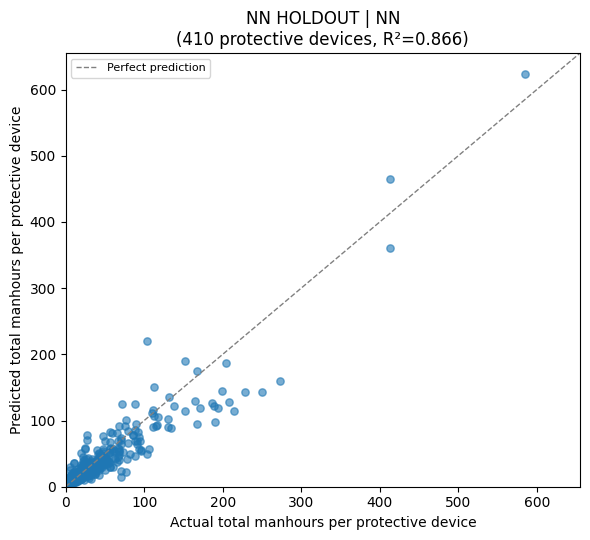

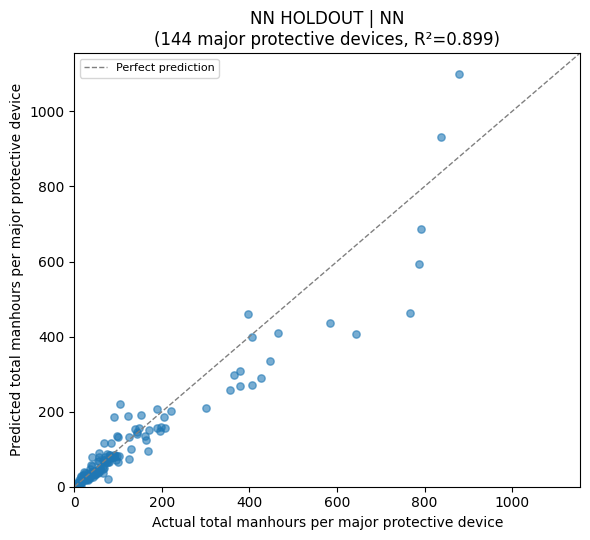


HOLDOUT - NN


Model,"NN (smooth_l1, w=1.82) HOLDOUT"
Accessible_MAE,1.1311
Inaccessible_MAE,2.5560
Combined_MAE,1.6673
Combined_R2,0.2990
Combined_Bias,-0.3792
Feeder_R2,0.9115
Feeder_WAPE,0.2188
Feeder_MdAPE,0.1889
Feeder_Within_15pct,0.3562
Feeder_Within_20pct,0.5068


Holdout 80% interval coverage: 0.820


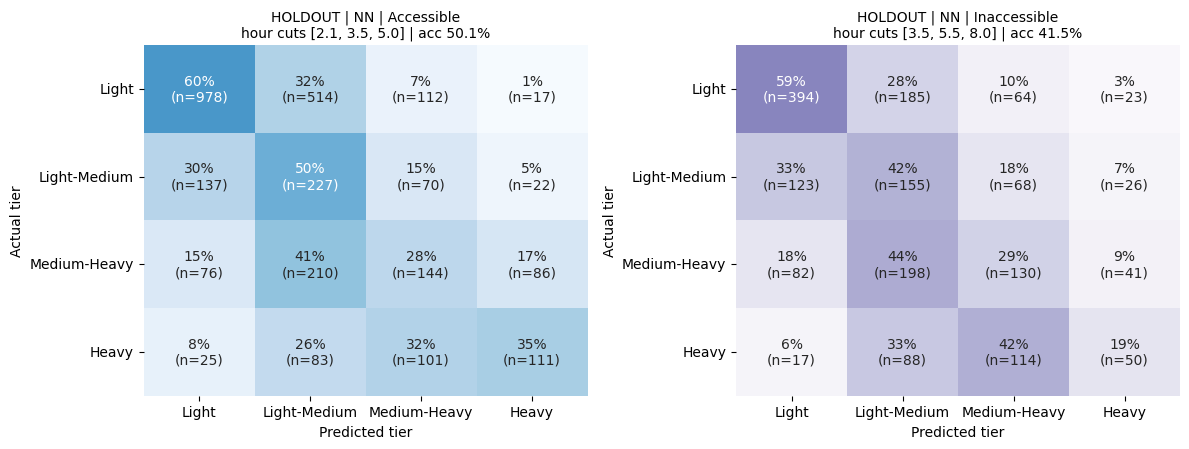

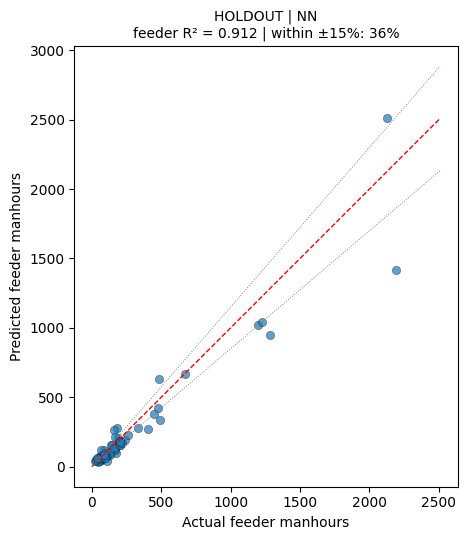

In [12]:
if not READY_FOR_FINAL_HOLDOUT:
    raise vp.HoldoutBreakpoint("READY_FOR_FINAL_HOLDOUT is False - NN development complete; holdout untouched.")

FINAL_FIT = ("train", "valid", "test")
print("=" * 72 + "\nHOLDOUT IS BEING SCORED - NN\n" + "=" * 72)
final_nets = fit_ensemble(BEST_SPEC, FINAL_FIT, seeds)
hold_out = predict_ensemble(final_nets, "holdout")
h_meta, y_hold, X_hold = FULL_META["holdout"], FULL_Y["holdout"], FULL_X["holdout"]

hold_row = vp.evaluate_combined(f"{NN_NAME} HOLDOUT", y_hold, hold_out["point"], h_meta, HOUR_CUTS)

h_meta = vp.attach_device_columns(h_meta, DEVICE_MAP)
for device_col in vp.PROTECTIVE_DEVICE_COLS:
    vp.protective_device_scatter(
        {"NN": hold_out["point"]}, y_hold, h_meta, device_col,
        "NN HOLDOUT", fig(f"nn_holdout_{device_col}_scatter.png"), SHOW_PLOTS)
        
vp.show(pd.DataFrame([hold_row]).set_index("Model")[vp.COMPARE_COLS].T, "HOLDOUT - NN")
print(f"Holdout 80% interval coverage: {((y_hold >= hold_out['p10']) & (y_hold <= hold_out['p90'])).mean():.3f}")
vp.confusion_grid({"NN": hold_out["point"]}, y_hold, h_meta, HOUR_CUTS, "HOLDOUT",
                  fig("nn_holdout_hour_tier_confusion.png"), SHOW_PLOTS)
feeders = vp.feeder_scatter({"NN": hold_out["point"]}, y_hold, h_meta, "HOLDOUT",
                            fig("nn_holdout_feeder_scatter.png"), SHOW_PLOTS)["NN"]



NN HOLDOUT - hours tiers (PRIMARY)


N  Mean_Hours  Median_Hours  \
Accessibility Area     Veg_Tier                                      
Accessible    Urban    Light         635        2.03           2.0   
                       Light-Medium  407        2.78           2.0   
                       Medium-Heavy   88        4.32           4.0   
                       Heavy          15        3.56           4.0   
              Suburban Light         508        2.01           2.0   
                       Light-Medium  530        3.26           3.0   
                       Medium-Heavy  197        4.27           4.0   
                       Heavy          88        6.14           5.0   
              Rural    Light          73        1.81           1.0   
                       Light-Medium   97        2.70           2.0   
                       Medium-Heavy  142        3.90           4.0   
                       Heavy         133        5.10           6.0   
Inaccessible  Urban    Light         168        2.91           2.0   
                       Light-Medium   61        4.14           4.0   
                       Medium-Heavy   21        7.08           8.0   
                       Heavy           9        7.00           8.0   
              Suburban Light         390        3.44           3.0   
                       Light-Medium  475        6.04           6.0   
                       Medium-Heavy  293        7.88           8.0   
                       Heavy         107        8.33           7.5   
              Rural    Light          58        3.19           2.0   
                       Light-Medium   90        4.24           4.0   
                       Medium-Heavy   62        5.44           4.0   
                       Heavy          24        6.77           6.0   

                                     Mean_CI95_Low  Mean_CI95_High   P10  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light                  1.95            2.13  0.93   
                       Light-Medium           2.65            2.92  1.27   
                       Medium-Heavy           3.89            4.80  1.89   
                       Heavy                  2.62            4.53  2.40   
              Suburban Light                  1.91            2.11  0.91   
                       Light-Medium           3.07            3.46  1.28   
                       Medium-Heavy           3.93            4.65  1.91   
                       Heavy                  5.44            6.89  2.44   
              Rural    Light                  1.52            2.13  0.87   
                       Light-Medium           2.34            3.09  1.33   
                       Medium-Heavy           3.61            4.25  2.04   
                       Heavy                  4.84            5.36  2.58   
Inaccessible  Urban    Light                  2.62            3.22  1.34   
                       Light-Medium           3.53            4.79  1.67   
                       Medium-Heavy           5.71            8.45  1.89   
                       Heavy                  4.83            9.17  2.23   
              Suburban Light                  3.21            3.68  1.32   
                       Light-Medium           5.73            6.38  1.56   
                       Medium-Heavy           7.35            8.41  1.78   
                       Heavy                  7.34            9.33  2.21   
              Rural    Light                  2.58            3.91  1.37   
                       Light-Medium           3.76            4.79  1.70   
                       Medium-Heavy           4.73            6.17  2.00   
                       Heavy                  5.33            8.40  2.35   

                                      P50    P90  Pred_Width   MAE  Bias  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light         1.86   3.57        2.63  0.70 -0.17   
             

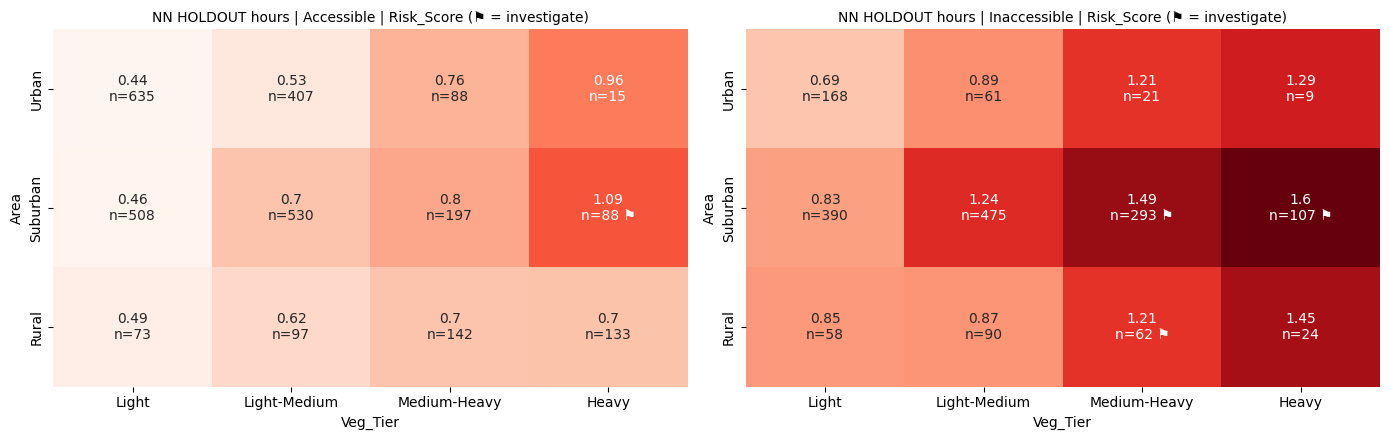


NN HOLDOUT - volume tiers


N  Mean_Hours  Median_Hours  \
Accessibility Area     Veg_Tier                                      
Accessible    Urban    Light         558        2.18           2.0   
                       Light-Medium  352        2.55           2.0   
                       Medium-Heavy  196        3.08           3.0   
                       Heavy          39        3.50           3.0   
              Suburban Light         482        2.33           2.0   
                       Light-Medium  356        3.07           2.0   
                       Medium-Heavy  285        3.32           3.0   
                       Heavy         200        4.83           4.0   
              Rural    Light          76        2.01           2.0   
                       Light-Medium   79        3.10           3.0   
                       Medium-Heavy   78        3.85           4.0   
                       Heavy         212        4.38           4.0   
Inaccessible  Urban    Light         113        2.66           2.0   
                       Light-Medium   80        4.26           3.0   
                       Medium-Heavy   48        4.96           4.0   
                       Heavy          18        4.14           3.5   
              Suburban Light         272        3.67           3.0   
                       Light-Medium  220        5.05           4.0   
                       Medium-Heavy  307        6.40           6.0   
                       Heavy         466        7.16           6.0   
              Rural    Light          39        3.82           3.0   
                       Light-Medium   42        3.74           3.0   
                       Medium-Heavy   44        4.81           4.0   
                       Heavy         109        5.03           4.0   

                                     Mean_CI95_Low  Mean_CI95_High   P10  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light                  2.06            2.31  1.01   
                       Light-Medium           2.41            2.70  1.18   
                       Medium-Heavy           2.89            3.29  1.35   
                       Heavy                  2.97            4.04  1.72   
              Suburban Light                  2.20            2.49  1.05   
                       Light-Medium           2.86            3.31  1.26   
                       Medium-Heavy           3.06            3.60  1.43   
                       Heavy                  4.38            5.30  1.86   
              Rural    Light                  1.68            2.36  1.09   
                       Light-Medium           2.75            3.47  1.48   
                       Medium-Heavy           3.35            4.42  1.81   
                       Heavy                  4.13            4.61  2.29   
Inaccessible  Urban    Light                  2.37            2.96  1.36   
                       Light-Medium           3.67            4.88  1.54   
                       Medium-Heavy           4.07            5.94  1.66   
                       Heavy                  2.94            5.50  1.69   
              Suburban Light                  3.32            4.06  1.39   
                       Light-Medium           4.59            5.55  1.57   
                       Medium-Heavy           5.93            6.89  1.60   
                       Heavy                  6.78            7.55  1.71   
              Rural    Light                  2.95            4.86  1.44   
                       Light-Medium           2.98            4.68  1.67   
                       Medium-Heavy           4.02            5.69  1.74   
                       Heavy                  4.47            5.66  1.93   

                                      P50    P90  Pred_Width   MAE  Bias  \
Accessibility Area     Veg_Tier                                            
Accessible    Urban    Light         2.03   3.88        2.87  0.81 -0.15   
             

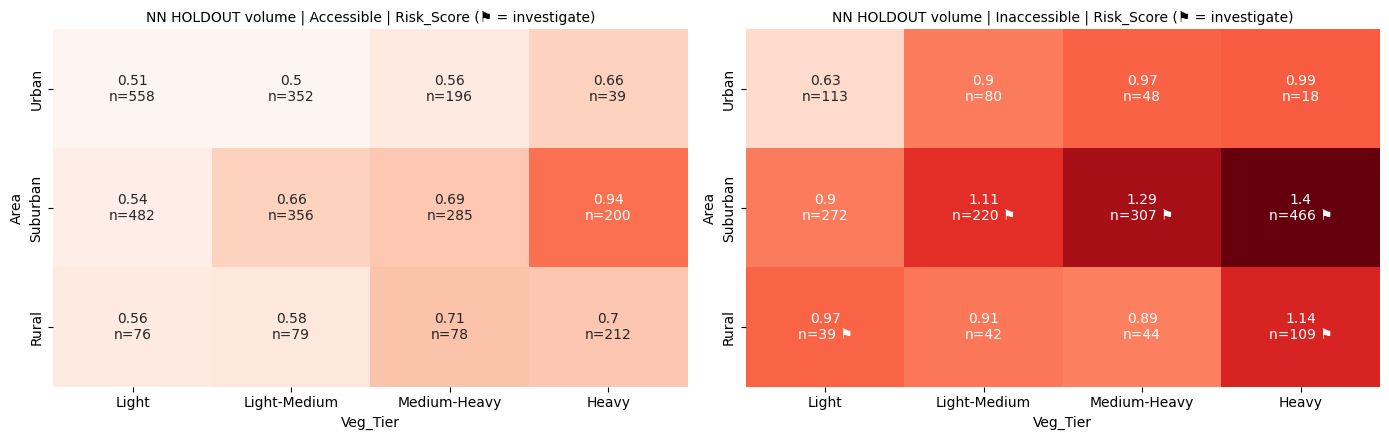


NN HOLDOUT - hour vs volume tier scheme


,Eta2_24class,Weighted_CV,Weighted_Abs_Class_Bias,Weighted_Risk,Max_Risk,Share_Spans_Flagged,Classes_Investigate,Classes_Low_N,Empty_Classes,Min_N
Scheme,,,,,,,,,,
hours,0.3392,0.6006,0.5380,0.7890,1.6001,0.1177,4,4,0,9
volume,0.2603,0.6536,0.5132,0.8038,1.4014,0.2443,5,1,0,18



NN HOLDOUT - classes to investigate


N  Mean_Hours    CV  Pred_Width  \
Scheme Accessibility Area     Veg_Tier                                          
hours  Inaccessible  Suburban Heavy         107        8.33  0.66       13.74   
                              Medium-Heavy  293        7.88  0.59       11.34   
                     Rural    Medium-Heavy   62        5.44  0.56       10.98   
       Accessible    Suburban Heavy          88        6.14  0.57        8.10   
volume Inaccessible  Suburban Heavy         466        7.16  0.62       10.15   
                              Medium-Heavy  307        6.40  0.65        8.48   
                     Rural    Heavy         109        5.03  0.62       10.19   
                     Suburban Light-Medium  220        5.05  0.72        7.51   
                     Rural    Light          39        3.82  0.81        5.60   

                                             MAE  Bias  Risk_Score  \
Scheme Accessibility Area     Veg_Tier                               
hours  Inaccessible  Suburban Heavy         4.33  0.40        1.60   
                              Medium-Heavy  3.62 -1.20        1.49   
                     Rural    Medium-Heavy  2.90  1.24        1.21   
       Accessible    Suburban Heavy         2.70 -0.56        1.09   
volume Inaccessible  Suburban Heavy         3.43 -1.21        1.40   
                              Medium-Heavy  2.97 -1.51        1.29   
                     Rural    Heavy         2.64  1.13        1.14   
                     Suburban Light-Medium  2.57 -0.76        1.11   
                     Rural    Light         2.21 -0.70        0.97   

                                                   Flagged_On  
Scheme Accessibility Area     Veg_Tier                         
hours  Inaccessible  Suburban Heavy            Pred_Width,MAE  
                              Medium-Heavy     Pred_Width,MAE  
                     Rural    Medium-Heavy     Pred_Width,MAE  
       Accessible    Suburban Heavy            Pred_Width,MAE  
volume Inaccessible  Suburban Heavy            Pred_Width,MAE  
                              Medium-Heavy     Pred_Width,MAE  
                     Rural    Heavy            Pred_Width,MAE  
                     Suburban Light-Medium  Pred_Width,CV,MAE  
                     Rural    Light                    CV,MAE


hours tiers - flagged on BOTH Test and Holdout


Test_Risk  Holdout_Risk  Holdout_N
Accessibility Area     Veg_Tier                                        
Accessible    Suburban Heavy              1.28          1.09         88
Inaccessible  Suburban Medium-Heavy       1.27          1.49        293
                       Heavy              1.74          1.60        107
              Rural    Medium-Heavy       1.29          1.21         62


volume tiers - flagged on BOTH Test and Holdout


Test_Risk  Holdout_Risk  Holdout_N
Accessibility Area     Veg_Tier                                        
Inaccessible  Suburban Light-Medium       1.01          1.11        220
                       Medium-Heavy       1.01          1.29        307
                       Heavy              1.27          1.40        466
              Rural    Heavy              1.26          1.14        109

NN holdout predictions, risk tables, models, and run log saved.


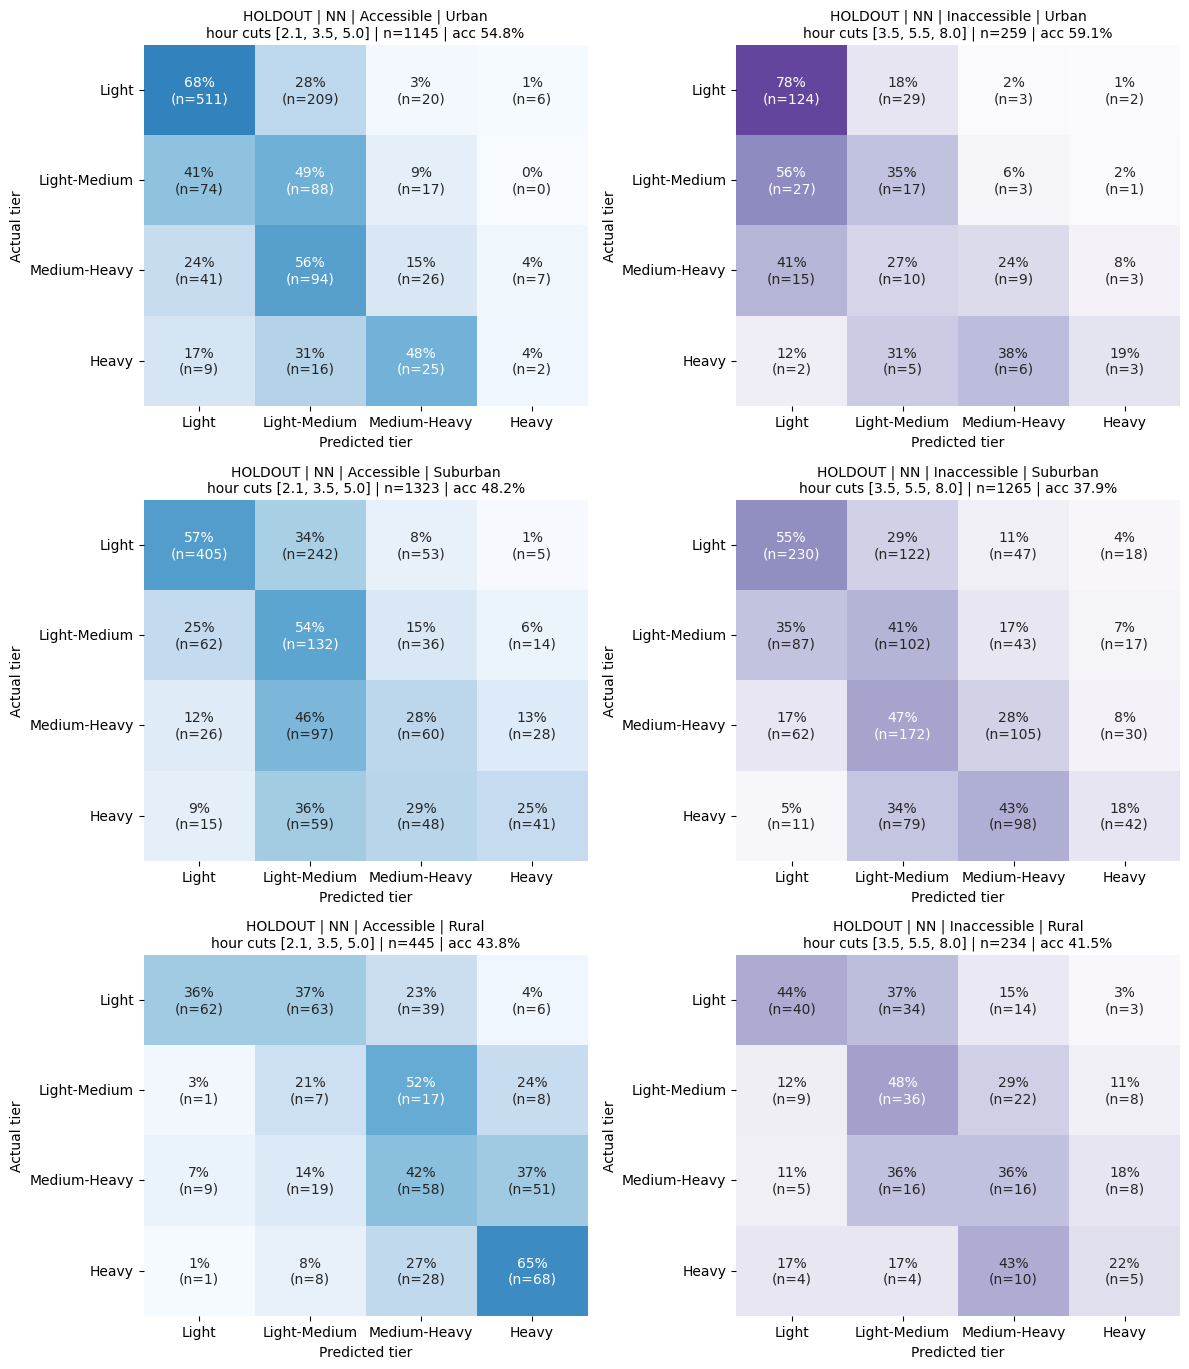

{'NN': <Figure size 1200x1380 with 6 Axes>}

In [13]:
NN_HOLD_RISK, NN_HOLD_SUMMARY, NN_HOLD_INVESTIGATE = risk_tables(
    "NN HOLDOUT", X_hold, y_hold, h_meta, hold_out["point"], hold_out["p10"], hold_out["point"], hold_out["p90"])
for n in SCHEMES:
    both = NN_TEST_RISK[n]["Investigate"] & NN_HOLD_RISK[n]["Investigate"]
    vp.show(pd.DataFrame({"Test_Risk": NN_TEST_RISK[n]["Risk_Score"], "Holdout_Risk": NN_HOLD_RISK[n]["Risk_Score"],
                          "Holdout_N": NN_HOLD_RISK[n]["N"]})[both], f"{n} tiers - flagged on BOTH Test and Holdout", 2)

out = h_meta.copy()
out["actual_manhours"] = y_hold
out[["nn_point", "nn_p10", "nn_p90"]] = hold_out[["point", "p10", "p90"]].to_numpy()
for n, scheme in SCHEMES.items():
    out[f"bid_tier_{n}"] = scheme.bid_labels(X_hold, hold_out["point"], h_meta)
out.to_csv(os.path.join(NN_DIR, "nn_holdout_predictions.csv"))
feeders.to_csv(os.path.join(NN_DIR, "nn_holdout_feeder_totals.csv"))
for n, t in NN_HOLD_RISK.items():
    t.to_csv(os.path.join(NN_DIR, f"nn_holdout_risk_table_{n}.csv"))
save_nets(final_nets, "final")
vp.append_holdout_log(os.path.join(OUTPUT_DIR, "holdout_run_log.jsonl"), {
    "timestamp": pd.Timestamp.now().isoformat(), "model": f"NN {BEST_SPEC}", "fit_splits": FINAL_FIT,
    "metrics": hold_row, "scheme_summary": NN_HOLD_SUMMARY.to_dict(orient="index")})
print("NN holdout predictions, risk tables, models, and run log saved.")

# Call function to produce confusion grids for each area class
vp.confusion_grid_by_area(
    {"NN": hold_out["point"]}, y_hold, h_meta, HOUR_CUTS, AREA_CLASS_COL,
    "HOLDOUT",
    area_classes=vp.AREA_CLASSES,
    save_path_template=fig("nn_holdout_hour_tier_confusion_by_area_{model}.png"),
    show_plot=SHOW_PLOTS,
)